<h1 style="text-align: center;">[Dekoruma Analysis]</h1>
<h3 style="text-align: center;">[Elmar Leonard and Firsa Adam]</h3>

---

## **Section 1. Business Context**

---

### **1.1 Context**

Dekoruma is a technology company founded in 2015 by Dimas Harry Priawan and Aruna Harsa, with a mission to drive efficiency in Indonesia’s home and living industry. The company addresses key consumer challenges: time-consuming furniture shopping, lack of price transparency, and difficulty finding designs that fit urban living spaces.
Recognizing that Indonesian consumers prefer to experience furniture before making high-value purchases, Dekoruma adopted an Online-to-Offline (O2O) model by establishing multiple Dekoruma Experience Centers (DEC) across major cities. This strategy has successfully enhanced customer trust and significantly boosted conversion rates.


---

### **1.2 Problem Statements**

Dekoruma currently faces a critical operational bottleneck: soaring return logistics costs coupled with a sharp decline in customer satisfaction. This double-edged challenge stems directly from a widening gap between furniture delivery schedules and assembly team arrivals. Compounding this issue, assembly teams frequently encounter missing components or damaged panels upon arrival. This forces immediate order cancellations and triggers expensive reverse logistics. Furthermore, Dekoruma Experience Centers (DECs) are experiencing a profound shift in utility; customers increasingly treat these showrooms as physical touchpoints to test products before purchasing them online. While DECs remain crucial for driving final purchasing decisions, this consumer shift leaves the physical centers with severely deflated performance metrics.

---

### **1.3 Key Objective**

1. **Logistics Synchronization:** Establish system architecture rules that mandate vehicle delivery (Rider) and assembly team (Installer) schedules occur on the exact same day, enforcing a strict maximum variance of 24 hours.
1. **Supplier Quality Control:** Implement a vendor penalty and blacklisting framework targeting furniture suppliers with the highest rates of missing components and defective panels.
1. **Omnichannel Attribution:** Restructure the sales data and attribution models to ensure DEC Sales Consultants receive accurate commission incentives when a customer transacts via the mobile app post-showroom visit.
1. **Data Cleansing:** Eradicate system vulnerabilities by introducing strict logical validations, blocking users from inputting assembly dates that precede a 'Delivered' shipping manifest status.


---

## **Section 2. Data Understanding**

---

### **2.1 Data Preparation**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import stats

from IPython.display import Image, display

import sys
import os

#### **Importing Function**

In [2]:
src_path = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if src_path not in sys.path:
    sys.path.append(src_path)

from utils import rename_cat, fill_ret_cost, extract_city, print_test

#### **Calling data**
> inserting all the data from csv into the notebook in form of dataframe

In [3]:
df_raw_orders = pd.read_csv(r"..\data\raw\dekoruma_orders.csv")
df_raw_products = pd.read_csv(r"..\data\raw\dekoruma_products.csv")
df_raw_stores = pd.read_csv(r"..\data\raw\dekoruma_stores.csv")

---

### **2.2 General Information**

#### **2.2.1 Checking orders columns information**
> checking the data in the dataframe. Checking like this would allow us to see the connection between each tables of data and what is the column with the type of data inside of the column. making us know what should we casting later on if it doesnt fit with the correct information we need just yet.

In [4]:
df_raw_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   order_id             300000 non-null  str  
 1   store_id             300000 non-null  str  
 2   sku_id               300000 non-null  str  
 3   order_date           300000 non-null  str  
 4   delivery_date        300000 non-null  str  
 5   installer_id         190275 non-null  str  
 6   installation_date    190275 non-null  str  
 7   installation_status  300000 non-null  str  
 8   assembly_fee         300000 non-null  int64
dtypes: int64(1), str(8)
memory usage: 51.2 MB


**Converting the columns that is supposed to be filled with datetime but filled with string into datetime**

In [5]:
df_raw_orders["order_date"] = pd.to_datetime(df_raw_orders["order_date"])
df_raw_orders["delivery_date"] = pd.to_datetime(df_raw_orders["delivery_date"])
df_raw_orders["installation_date"] = pd.to_datetime(df_raw_orders["installation_date"])

In [6]:
df_raw_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             300000 non-null  str           
 1   store_id             300000 non-null  str           
 2   sku_id               300000 non-null  str           
 3   order_date           300000 non-null  datetime64[us]
 4   delivery_date        300000 non-null  datetime64[us]
 5   installer_id         190275 non-null  str           
 6   installation_date    190275 non-null  datetime64[us]
 7   installation_status  300000 non-null  str           
 8   assembly_fee         300000 non-null  int64         
dtypes: datetime64[us](3), int64(1), str(5)
memory usage: 36.8 MB


#### **2.2.2 Checking products columns information**
> checking the data in the dataframe. Checking like this would allow us to see the connection between each tables of data and what is the column with the type of data inside of the column. making us know what should we casting later on if it doesnt fit with the correct information we need just yet.

In [7]:
df_raw_products.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   sku_id                1500 non-null   str  
 1   product_name          1500 non-null   str  
 2   category              1500 non-null   str  
 3   is_assembly_required  1500 non-null   bool 
dtypes: bool(1), str(3)
memory usage: 106.5 KB


#### **2.2.3 Checking stores columns information**
> checking the data in the dataframe. Checking like this would allow us to see the connection between each tables of data and what is the column with the type of data inside of the column. making us know what should we casting later on if it doesnt fit with the correct information we need just yet.

In [8]:
df_raw_stores.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   store_id      40 non-null     str  
 1   store_name    40 non-null     str  
 2   channel_type  40 non-null     str  
dtypes: str(3)
memory usage: 2.5 KB


---

### **2.3 Feature Information**

#### **2.3.1 In-depth Information Table Orders**

| Column Names         | Description                             |
|----------------------|-----------------------------------------|
| `order_id`           | Unique identifier for each order transaction | 
| `store_id`           | Unique identifier for the store or sales channel where the order was placed | 
| `sku_id`             | Unique identifier for the ordered product | 
| `order_date`         | Date and time when the order was placed by the customer |
| `delivery_date`      | Date and time when the product was delivered to the customer's location |
| `installer_id`       | Unique identifier for the assigned furniture installation technician |
| `installation_date`  | Date and time when the furniture installation was performed; defaults to `NaN` if no installation occurred | 
| `installation_status`| Final outcome status of the furniture installation (*Success* / *Failed - Missing Parts* / *Failed - Damaged Panel* / *No Assembly Service* / *No Assembly Required*) |
| `assembly_fee`       | Furniture installation service fee in Indonesian Rupiah (IDR); defaults to `0` if no installation occurred |

#### **2.3.2 In-depth Information Table Products**

| Column Names          | Description                             |
|-----------------------|-----------------------------------------|
| `sku_id`              | Unique identifier for the product | 
| `product_name`        | Full name of the furniture product |
| `category`            | Furniture product category (e.g., *Wardrobe*, *Sofa*, *Office Chair*, *Dining Table*, etc.) |
| `is_assembly_required`| Boolean indicator specifying whether the product requires assembly (`True`) or not (`False`) |

#### **2.3.3 In-depth Information Table Stores**

| Column Names       | Description                             |
|--------------------|-----------------------------------------|
| `store_id`         | Unique identifier for the store or sales channel | 
| `store_name`       | Name of the store or sales channel (e.g., *DEC Alam Sutera*, *Mobile App*, *Web*) | 
| `channel_type`     | Type of sales channel: *Physical Store* (DEC brick-and-mortar stores), *Mobile App*, or *Web* |

---

### **2.4 Statistics Summary**

#### **2.4.1 Checking orders columns description**
> checking the statistics information in the dataframe. Checking like this would allow us to see the statistics information on the table which have numerical values.

In [9]:
df_raw_orders.describe()

,order_date,delivery_date,installation_date,assembly_fee
count,300000,300000,190275,3.000000e+05
mean,2023-07-02 10:44:26.988000,2023-07-06 22:47:19.500000,2023-07-09 13:13:20.296412,4.044456e+05
min,2023-01-01 09:00:00,2023-01-03 09:00:00,2023-01-01 12:00:00,-1.500000e+05
25%,2023-04-02 11:00:00,2023-04-06 17:00:00,2023-04-09 14:00:00,0.000000e+00
50%,2023-07-02 14:00:00,2023-07-06 20:00:00,2023-07-09 13:00:00,9.000000e+04
75%,2023-10-01 16:00:00,2023-10-06 11:00:00,2023-10-08 20:00:00,1.700000e+05
max,2023-12-31 20:00:00,2024-01-07 20:00:00,2024-01-12 18:00:00,9.990000e+07
std,NaN,NaN,NaN,5.557956e+06


**Key Insights from Orders Summary Statistics**

An analysis of the `describe()` output for the `orders` dataset reveals several critical data characteristics and operational insights:

1. **Robust Data Volume:** The dataset contains **300,000 transaction rows** (`count = 300,000`), demonstrating a substantial operational scale and providing a highly representative sample for reliable business analysis.

2. **Dominance of Non-Assembly Orders:** The first quartile (`Q1 = 0`) indicates that more than 25% of all orders incur an `assembly_fee` of zero. This confirms that a significant portion of transactions involves products that do not require assembly services, aligning perfectly with items where `is_assembly_required = False`.

3. **Standard Assembly Fee Range:** With a `median = 90,000` and `Q3 = 170,000`, typical furniture installation fees realistically fluctuate between **IDR 50,000 and IDR 250,000**. This baseline represents standard, logical pricing for residential furniture installation services in Indonesia.

4. **Negative Value Anomaly:** A minimum value of `-150,000` represents a business-illogical anomaly, as assembly fees cannot be negative. This points directly to a **system input or processing error** that must be resolved during the data-clearing phase.

5. **Extreme Upper-Bound Anomaly:** The maximum value reaches `99,900,000`, which vastly deviates from the `Q3` threshold. This extreme figure is highly likely a **system sentinel value or placeholder** used to flag specific system states rather than an actual service charge, requiring targeted isolation during anomaly detection.

6. **Severe Right-Skewed Distribution:** The standard deviation (`std = 5,557,956`) drastically exceeds the mean. This indicates a **heavily right-skewed distribution**, heavily distorted by the presence of the `99,900,000` extreme outlier values.


---

## **Section 3. Data Cleaning**

---

### **3.1 Missing Values**

---

#### **3.1.1 Checking missing value data using isnull method**
> in this step we would be able to see how many null data inside each table so we can conclude why the data is missing and what should we do with it

In [10]:
print("=== ORDERS TABLE ===")
print(df_raw_orders.isnull().sum())

print("\n=== PRODUCTS TABLE ===")
print(df_raw_products.isnull().sum())

print("\n=== STORES TABLE ===")
print(df_raw_stores.isnull().sum())

=== ORDERS TABLE ===
order_id                    0
store_id                    0
sku_id                      0
order_date                  0
delivery_date               0
installer_id           109725
installation_date      109725
installation_status         0
assembly_fee                0
dtype: int64

=== PRODUCTS TABLE ===
sku_id                  0
product_name            0
category                0
is_assembly_required    0
dtype: int64

=== STORES TABLE ===
store_id        0
store_name      0
channel_type    0
dtype: int64


---

#### **3.1.2 In-Depth Dive into Missing Values**
> in this step we would dive deeper on the missing value on orders table to decide what type of missing value it is. is it MNAR, MAR, or MCAR.

**As we can see both missing value is on installer_id and installer date so we could check if the data missing is on the same row as it have the same amount of missing values**

In [11]:
df_raw_orders[(df_raw_orders["installer_id"].isnull())&(df_raw_orders["installation_date"].isnull())].head()

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
4,ORD-DKR00000005,DKR-019,SKU-FURN-01500,2023-12-15 12:00:00,2023-12-22 12:00:00,NaN,NaT,No Assembly Service,0
6,ORD-DKR00000007,DKR-025,SKU-FURN-01195,2023-02-14 09:00:00,2023-02-19 09:00:00,NaN,NaT,No Assembly Required,0
8,ORD-DKR00000009,DKR-022,SKU-FURN-00766,2023-07-29 13:00:00,2023-08-02 13:00:00,NaN,NaT,No Assembly Required,0
9,ORD-DKR00000010,DKR-026,SKU-FURN-01470,2023-12-29 10:00:00,2024-01-02 10:00:00,NaN,NaT,No Assembly Required,0
13,ORD-DKR00000014,DKR-020,SKU-FURN-01242,2023-07-02 14:00:00,2023-07-05 14:00:00,NaN,NaT,No Assembly Required,0


**from the result we can see that the row that have missing values is still 109725 even after we use a condition to call rows that have missing values on both installer_id and installation_date. Other than that as we now knew both of them correlated we can see as well all of the data that have missing row have assembly_fee of 0, with this we can make a first assumption that the data is missing not at random but because it has no assembly fee.**

---

#### **3.1.3 Testing first assumption**

In [12]:
df_raw_orders[(df_raw_orders["installer_id"].isnull())&(df_raw_orders["installation_date"].isnull())&(df_raw_orders["assembly_fee"]>0)]

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee


**from this code we can conclude that the first assumption is correct with no rows with null values if the assembly fee is larger than zero. now we can do a more in depth research using installation status of each type**

In [13]:
df_raw_orders["installation_status"].unique()

<ArrowStringArray>
[               'Success',    'No Assembly Service',   'No Assembly Required',
 'Failed - Missing Parts', 'Failed - Damaged Panel']
Length: 5, dtype: str

**Checking if there is a null value in Success Status**

In [14]:
df_raw_orders[(df_raw_orders["installation_status"]=="Success")&(df_raw_orders["installer_id"].isnull())]

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee


**Checking if there is a null value in Failed - Missing Parts Status**

In [15]:
df_raw_orders[(df_raw_orders["installation_status"]=="Failed - Missing Parts")&(df_raw_orders["installer_id"].isnull())]

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee


**Checking if there is a null value in Failed - Damage Panel Status**

In [16]:
df_raw_orders[(df_raw_orders["installation_status"]=="Failed - Damage Panel")&(df_raw_orders["installer_id"].isnull())]

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee


**Checking if there is a null value in No Assembly Service Status**

In [17]:
display(df_raw_orders[(df_raw_orders["installation_status"]=="No Assembly Service")&(df_raw_orders["installer_id"].isnull())].head())
print(f"total row with null value: {df_raw_orders[(df_raw_orders["installation_status"]=="No Assembly Service")&(df_raw_orders["installer_id"].isnull())].shape[0]}")

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
4,ORD-DKR00000005,DKR-019,SKU-FURN-01500,2023-12-15 12:00:00,2023-12-22 12:00:00,NaN,NaT,No Assembly Service,0
27,ORD-DKR00000028,DKR-021,SKU-FURN-01464,2023-10-18 12:00:00,2023-10-20 12:00:00,NaN,NaT,No Assembly Service,0
38,ORD-DKR00000039,DKR-021,SKU-FURN-00911,2023-05-15 14:00:00,2023-05-19 14:00:00,NaN,NaT,No Assembly Service,0
73,ORD-DKR00000074,DKR-035,SKU-FURN-00348,2023-02-03 13:00:00,2023-02-05 13:00:00,NaN,NaT,No Assembly Service,0
79,ORD-DKR00000080,DKR-032,SKU-FURN-01049,2023-03-21 10:00:00,2023-03-27 10:00:00,NaN,NaT,No Assembly Service,0


total row with null value: 33695


**Checking if there is a null value in No Assembly Required Status**

In [18]:
display(df_raw_orders[(df_raw_orders["installation_status"]=="No Assembly Required")&(df_raw_orders["installer_id"].isnull())].head())
print(f"total row with null value: {df_raw_orders[(df_raw_orders["installation_status"]=="No Assembly Required")&(df_raw_orders["installer_id"].isnull())].shape[0]}")

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
6,ORD-DKR00000007,DKR-025,SKU-FURN-01195,2023-02-14 09:00:00,2023-02-19 09:00:00,NaN,NaT,No Assembly Required,0
8,ORD-DKR00000009,DKR-022,SKU-FURN-00766,2023-07-29 13:00:00,2023-08-02 13:00:00,NaN,NaT,No Assembly Required,0
9,ORD-DKR00000010,DKR-026,SKU-FURN-01470,2023-12-29 10:00:00,2024-01-02 10:00:00,NaN,NaT,No Assembly Required,0
13,ORD-DKR00000014,DKR-020,SKU-FURN-01242,2023-07-02 14:00:00,2023-07-05 14:00:00,NaN,NaT,No Assembly Required,0
15,ORD-DKR00000016,DKR-016,SKU-FURN-01458,2023-05-20 13:00:00,2023-05-22 13:00:00,NaN,NaT,No Assembly Required,0


total row with null value: 76030


---

#### **3.1.4 Strategy for Handling Missing Values**

**Conclusion**  
A deeper investigation into the dataset reveals that the missing data is **Missing Not at Random (MNAR)**. The absence of entries in the `installer_id` and `installation_date` columns follows a strict business logic: when a product does not require assembly or when no assembly service is selected for that order, these fields are systematically left blank. Because these missing values carry critical contextual meaning rather than representing data corruption, removing these rows would result in a significant loss of information. Instead of dropping the data, the missing values will be preserved and handled using a condition-specific approach to maintain historical and analytical accuracy:

* **`installer_id` Treatment**: Missing values will be imputed with the string **"NO INSTALLER"**. This explicitly clarifies that the transaction did not involve an installation technician, differentiating it from an error.
* **`installation_date` Treatment**: Missing entries will be **left blank (or preserved as null values)**. This strategy preserves data integrity by accurately reflecting historical reality—since no installation was required or requested, an installation event never occurred.

In [19]:
# fill installer_id 
df_raw_orders["installer_id"] = df_raw_orders["installer_id"].fillna("NO INSTALLER")

In [20]:
df_raw_orders.head()

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
0,ORD-DKR00000001,DKR-029,SKU-FURN-00208,2023-08-10 17:00:00,2023-08-14 17:00:00,TUKANG-0882,2023-08-18 17:00:00,Success,120000
1,ORD-DKR00000002,DKR-012,SKU-FURN-01157,2023-01-30 10:00:00,2023-02-02 10:00:00,TUKANG-0560,2023-02-02 10:00:00,Success,110000
2,ORD-DKR00000003,DKR-032,SKU-FURN-00904,2023-07-13 20:00:00,2023-07-19 20:00:00,TUKANG-0631,2023-07-24 20:00:00,Success,230000
3,ORD-DKR00000004,DKR-005,SKU-FURN-00341,2023-09-27 19:00:00,2023-10-02 19:00:00,TUKANG-0484,2023-10-04 19:00:00,Success,100000
4,ORD-DKR00000005,DKR-019,SKU-FURN-01500,2023-12-15 12:00:00,2023-12-22 12:00:00,NO INSTALLER,NaT,No Assembly Service,0


---

### **3.2 Duplicated Values**

---

#### **3.2.1 Checking duplicated values in every table**
> in this step we would be able to see how many duplicated data inside each table so we can conclude why the data is duplicated and what should we do with it

In [21]:
print(f"Total Duplicate Row in Orders Table: {df_raw_orders.duplicated().sum()}")
print(f"Total Duplicate Row in Products Table: {df_raw_products.duplicated().sum()}")
print(f"Total Duplicate Row in Stores Table: {df_raw_stores.duplicated().sum()}")

Total Duplicate Row in Orders Table: 0
Total Duplicate Row in Products Table: 0
Total Duplicate Row in Stores Table: 0


**No duplicated row found**

---

### **3.3 Identify Spelling Errors**

---

#### **3.3.1 Checking spelling value data using unique method**
> in this step we would be able to see how many unique data inside each table so we can conclude if the value spelling is error or not

In [22]:
df_raw_stores["store_name"].unique()

<ArrowStringArray>
[   'DEC Alam Sutera 1',        'DEC Bintaro 2',         'DEC Kemang 3',
  'DEC Kelapa Gading 4',          'DEC Medan 5',         'DEC Kemang 6',
       'DEC Surabaya 7',        'DEC Bandung 8',  'DEC Kelapa Gading 9',
        'DEC Kemang 10', 'DEC Kelapa Gading 11',       'DEC Bintaro 12',
      'DEC Surabaya 13', 'DEC Kelapa Gading 14',        'DEC Bekasi 15',
        'DEC Bekasi 16',         'DEC Medan 17',   'DEC Alam Sutera 18',
   'DEC Alam Sutera 19',      'DEC Surabaya 20',        'DEC Bekasi 21',
   'DEC Alam Sutera 22', 'DEC Kelapa Gading 23',   'DEC Alam Sutera 24',
        'DEC Bekasi 25',       'DEC Bandung 26',   'DEC Alam Sutera 27',
      'DEC Surabaya 28', 'DEC Kelapa Gading 29',        'DEC Kemang 30',
       'DEC Bintaro 31',         'DEC Medan 32',   'DEC Alam Sutera 33',
       'DEC Bintaro 34',      'DEC Surabaya 35',   'DEC Alam Sutera 36',
 'DEC Kelapa Gading 37',       'DEC Bintaro 38',  'Dekoruma Mobile App',
     'Dekoruma Website']
Length:

In [23]:
df_raw_stores["channel_type"].unique()

<ArrowStringArray>
['Physical Store', 'Mobile App', 'Web']
Length: 3, dtype: str

In [24]:
df_raw_products["category"].unique()

<ArrowStringArray>
['Office Chair',     'Wardrobe',         'Sofa',  'Kursi Kerja',
       'Lemari',      'sofabed',     'Dekorasi', 'Dining Table',
         'lmri',   'Meja Makan',          'Bed']
Length: 11, dtype: str

**As we can see from the unique tested on some columns in the the table there are some values that is misspelled or differently written eventhough it describe the same category.**

---

#### **3.3.2 In-depth Analysis on Each Similiar Category**

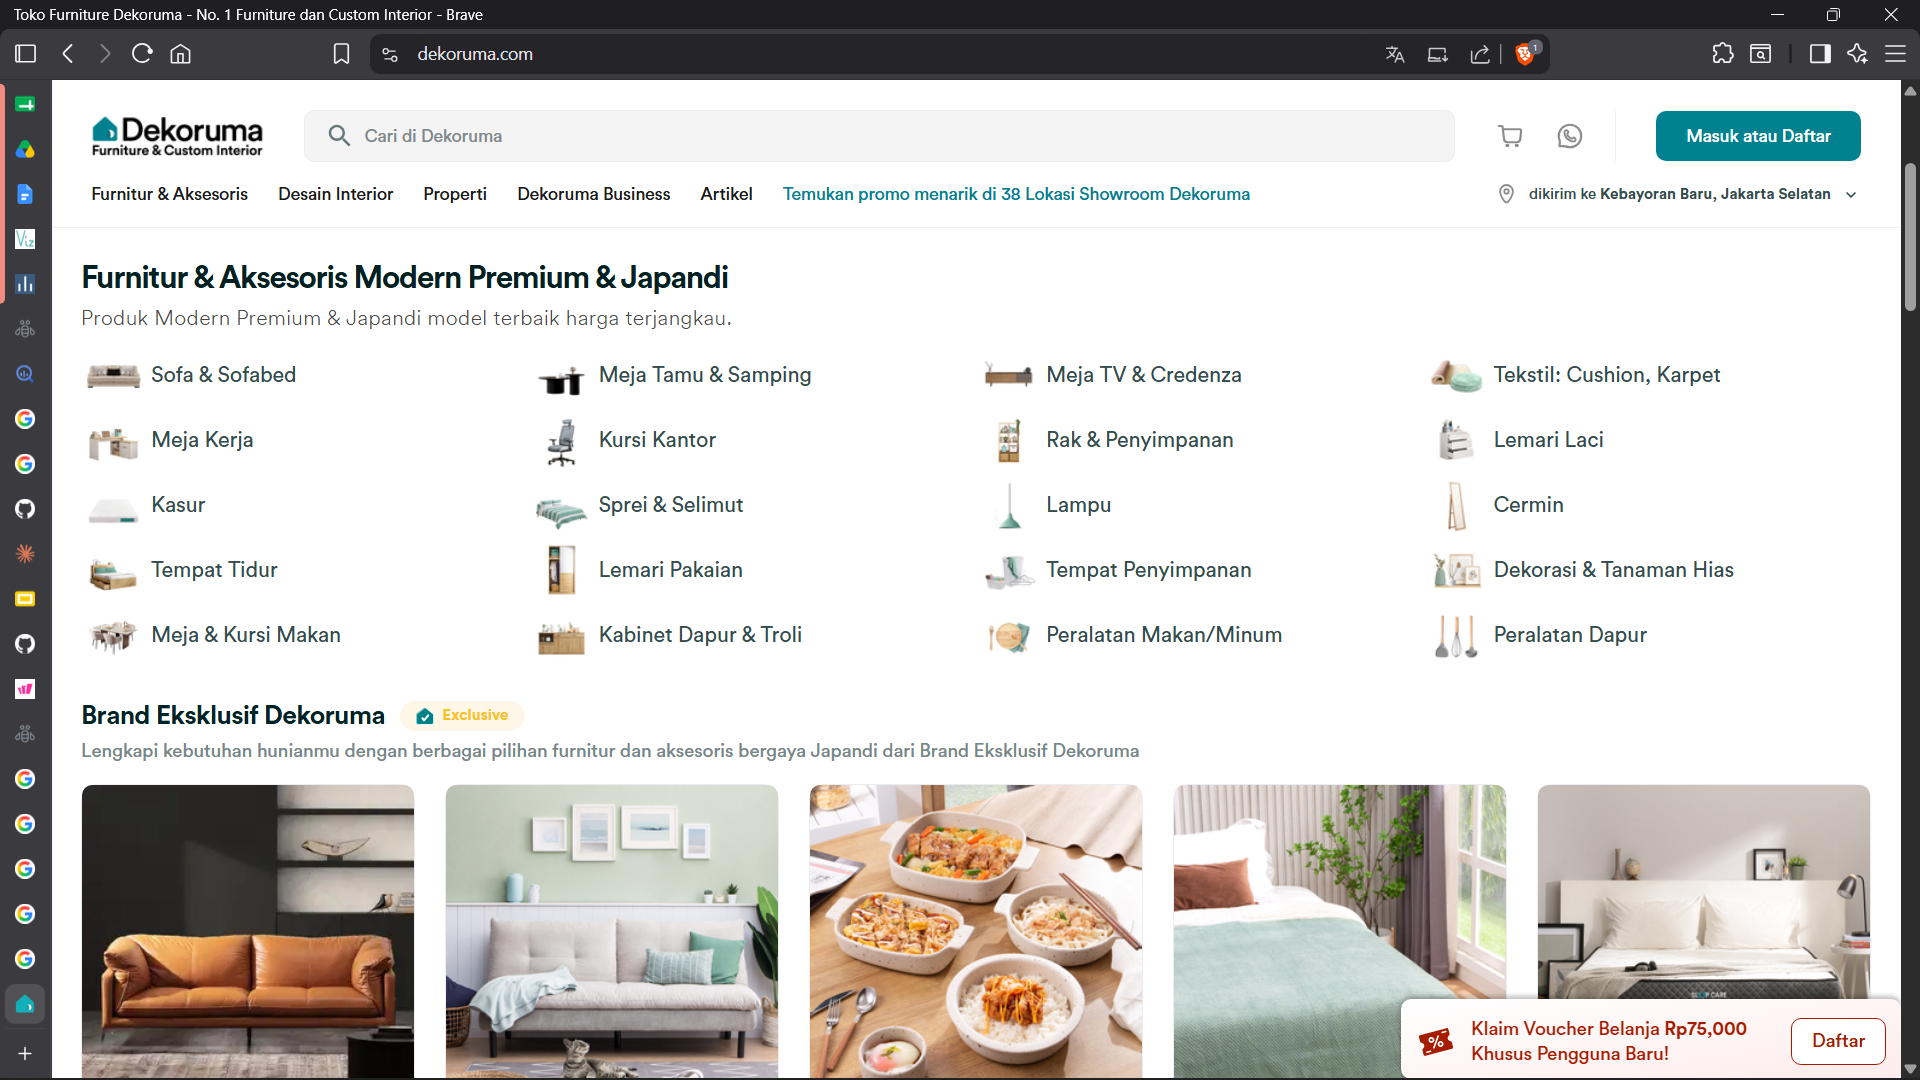

In [25]:
display(Image(filename=r"..\src\Furniture Types.png"))

1. **Sofa and sofabed is included in one category**
1. **Office chair is only one category**
1. **Wardrobe is only one category**
1. **Dining Table is only one category**

**Based on that information we would do some changing on the category so it will be in uniform**

In [26]:
df_raw_products["category"] = df_raw_products["category"].apply(lambda x: rename_cat(x))

In [27]:
df_raw_products["category"].unique()

<ArrowStringArray>
[  'Office Chair',       'Wardrobe', 'Sofa & Sofabed',     'Decoration',
   'Dining Table',            'Bed']
Length: 6, dtype: str

---

### **3.4 Identify Anomaly Values**

---

#### **3.4.1 Checking anomaly values in data using boxplot**
> in this step we would be able to see how many outlier in the data set

**Making boxplot to allow us do an observation based on chart**

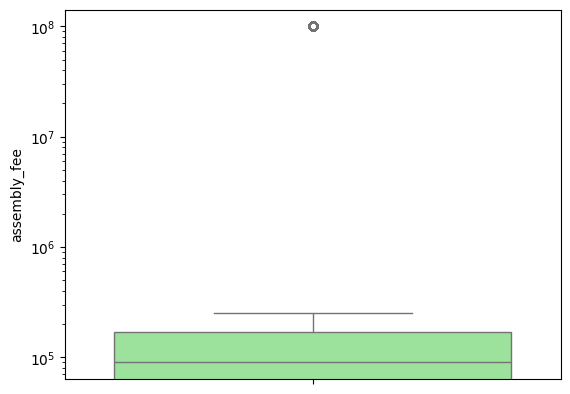

In [28]:
sns.boxplot(df_raw_orders["assembly_fee"], color="lightgreen").set_yscale('log')

**As we can see from the boxplot there are outliers in the assembly_fee column, next what we can do by knowing this information is to do an in-depth analysis on the column to know the outlier even better**

---

#### **3.4.2 Checking anomaly values in data using IQR**
> We do this so we could now in-depth information about the outlier like how many there are and what is the assembly fee outlier value so we can analyze why it is an outlier

In [29]:
q1 = df_raw_orders["assembly_fee"].quantile(0.25)
q3 = df_raw_orders["assembly_fee"].quantile(0.75)
iqr = q3 - q1

upper = q3 + (iqr * 1.5)
lower = q1 - (iqr * 1.5)

print(f"total outlier: {df_raw_orders[(df_raw_orders["assembly_fee"]>upper)|(df_raw_orders["assembly_fee"]<lower)]["order_id"].count()}")

total outlier: 933


In [30]:
print(f"unique outlier value: {df_raw_orders[(df_raw_orders["assembly_fee"]>upper)]["assembly_fee"].unique()}")

unique outlier value: [99900000]


In [31]:
outlier_pos = df_raw_orders[df_raw_orders['assembly_fee'] == 99900000]
print("=== installation_status on Outlier ===")
print(outlier_pos['installation_status'].value_counts().reset_index())
print("Total positif outlier:", outlier_pos.value_counts().sum())

=== installation_status on Outlier ===
      installation_status  count
0                 Success    748
1  Failed - Missing Parts    111
2  Failed - Damaged Panel     74
Total positif outlier: 933


**from that unique outlier value we can see all `933` outlier have the same value `99,900,000`**

---

#### **3.4.3 Checking Anomaly values**
> in this anomaly check phase we would check if there is a valuer that not fit the supposed value of the columns

In [32]:
anomaly_negative_count = (df_raw_orders['assembly_fee'] < 0).sum()
print("negative outlier:", anomaly_negative_count)

negative outlier: 960


In [33]:
anomaly_neg = df_raw_orders[df_raw_orders['assembly_fee'] < 0]
print("=== installation_status on Negative Fee Anomaly ===")
print(anomaly_neg['installation_status'].value_counts().reset_index())
print("Total negative fee anomaly:", anomaly_neg.value_counts().sum())

=== installation_status on Negative Fee Anomaly ===
      installation_status  count
0                 Success    786
1  Failed - Missing Parts    100
2  Failed - Damaged Panel     74
Total negative fee anomaly: 960


In [34]:
df_raw_orders[df_raw_orders["assembly_fee"] < 0]["assembly_fee"].unique()

array([-150000])

**From that check we can see all 960 anomaly value are not in the same installation status, and also the unique value of all the `960` negative fee they are all `-150,000` so it is not a sign flip glitch in the system**

---

#### **3.4.4 Checking Logical error in the Data**
> in this anomaly check phase we would check if there is a logical error in the data columns

**Delivery date happened before order date**

In [35]:
display(df_raw_orders[(df_raw_orders["delivery_date"] < df_raw_orders["order_date"])])
print(f"Total row with the logical error: {df_raw_orders[(df_raw_orders["delivery_date"] < df_raw_orders["order_date"])].shape[0]}")

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee


Total row with the logical error: 0


**Installation date happened before order date**

In [36]:
display(df_raw_orders[(df_raw_orders["installation_date"] < df_raw_orders["order_date"])].head())
print(f"Total row with the logical error: {df_raw_orders[(df_raw_orders["installation_date"] < df_raw_orders["order_date"])].shape[0]}")

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
475,ORD-DKR00000476,DKR-004,SKU-FURN-00677,2023-03-19 15:00:00,2023-03-21 15:00:00,TUKANG-0127,2023-03-18 15:00:00,Success,250000
1851,ORD-DKR00001852,DKR-006,SKU-FURN-00041,2023-12-19 18:00:00,2023-12-21 18:00:00,TUKANG-0428,2023-12-18 18:00:00,Success,120000
2255,ORD-DKR00002256,DKR-018,SKU-FURN-00828,2023-07-18 10:00:00,2023-07-20 10:00:00,TUKANG-0136,2023-07-17 10:00:00,Success,50000
2615,ORD-DKR00002616,DKR-028,SKU-FURN-00120,2023-04-30 15:00:00,2023-05-02 15:00:00,TUKANG-0748,2023-04-29 15:00:00,Success,230000
2791,ORD-DKR00002792,DKR-019,SKU-FURN-00134,2023-02-22 16:00:00,2023-02-24 16:00:00,TUKANG-0938,2023-02-21 16:00:00,Success,140000


Total row with the logical error: 247


**Installation date happened before delivery date**

In [37]:
display(df_raw_orders[(df_raw_orders["installation_date"] < df_raw_orders["delivery_date"])].head())
print(f"Total row with the logical error: {df_raw_orders[(df_raw_orders["installation_date"] < df_raw_orders["delivery_date"])].shape[0]}")

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
180,ORD-DKR00000181,DKR-032,SKU-FURN-01054,2023-07-28 11:00:00,2023-07-31 11:00:00,TUKANG-0844,2023-07-28 11:00:00,Success,90000
247,ORD-DKR00000248,DKR-040,SKU-FURN-00870,2023-10-20 19:00:00,2023-10-25 19:00:00,TUKANG-0652,2023-10-24 19:00:00,Success,50000
267,ORD-DKR00000268,DKR-015,SKU-FURN-00679,2023-04-10 13:00:00,2023-04-17 13:00:00,TUKANG-0508,2023-04-15 13:00:00,Success,70000
287,ORD-DKR00000288,DKR-021,SKU-FURN-00934,2023-08-07 19:00:00,2023-08-14 19:00:00,TUKANG-0810,2023-08-12 19:00:00,Success,250000
369,ORD-DKR00000370,DKR-026,SKU-FURN-00128,2023-08-30 14:00:00,2023-09-06 14:00:00,TUKANG-0340,2023-09-04 14:00:00,Success,90000


Total row with the logical error: 4570


In [38]:
print(f"Percentage of Logical Error Rows: {(df_raw_orders[(df_raw_orders["installation_date"]<df_raw_orders["delivery_date"])|(df_raw_orders["installation_date"]<df_raw_orders["order_date"])].shape[0]/df_raw_orders.shape[0]):.2%}")

Percentage of Logical Error Rows: 1.52%


**From that check we can see the total of logical error rows are 1.52%**

---

#### **3.4.5 Strategy for Handling Outlier, Anomaly and Logical Error Values**

**Conclusion**

An analysis of the dataset revealed critical data integrity issues, spanning systematic fee anomalies and flawed timeline logic:

* **Fee Anomalies (Systemic Signal)**: The `assembly_fee` column contains severe outliers including **933 rows** of placeholder values (`99,900,000`) and **960 rows** of impossible negative fees (`< 0`). Because these errors cut evenly across all operational outcomes (*Success*, *Failed - Missing Parts*, *Failed - Damaged Panel*), they stem from upstream system configurations or faulty default settings rather than human operational errors.
* **Timeline Inconsistencies (Process Logic)**: Chronological order is broken in two areas, where the installation date precedes the order date (**247 rows**) or the delivery date (**4,570 rows**). These errors impact **1.52% of the total dataset**, pointing to sync issues between independent backend logging systems.

**Key Insight:** The random distribution of fee errors combined with the sequential breakdown of date tracking suggests that these are not localized human slip-ups. Instead, they represent fundamental data pipeline vulnerabilities—specifically weak frontend form validation and asynchronous database write-times—that must be resolved at the source database level to prevent skewing downstream financial metrics.

**Data Remediation Strategies**

To ensure our business metrics and visualizations remain accurate, we should apply distinct treatment strategies:

* **Fee Anomalies: Median Imputation or Segmentation**
    * **Action**: Flagging the anomalies with system error to give identification to the value and then replace both the negative values and `99,900,000` placeholders with the **overall median** of valid assembly fees. The median naturally ignores extreme outliers and reflects the actual "typical" fee.
    * **Business Rationale**: The 1,893 rows with fee errors still contain perfectly valid information regarding *what* was bought, *who* bought it, and *when* it was installed. Dropping them means losing visibility into those associated products, dates, and customer profiles.

* **Timeline Inconsistencies: Drop Rows**
    * **Action**: Exclude the 4,817 affected rows from active reporting.
    * **Business Rationale**: Chronological logic is absolute. Keeping these rows will break metrics like "Average Days to Install." Since they represent only 1.52% of the data, removing them preserves metric integrity without sacrificing data volume.

In [39]:
# Flagging anomalies fee
df_raw_orders = df_raw_orders.assign(is_system_error=lambda x: (x["assembly_fee"] < 0) | (x["assembly_fee"] == 99900000))

df_raw_orders[df_raw_orders["is_system_error"] == True].head()

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee,is_system_error
383,ORD-DKR00000384,DKR-029,SKU-FURN-00385,2023-07-14 20:00:00,2023-07-19 20:00:00,TUKANG-0115,2023-07-19 20:00:00,Success,-150000,True
436,ORD-DKR00000437,DKR-013,SKU-FURN-01362,2023-08-22 16:00:00,2023-08-27 16:00:00,TUKANG-0410,2023-08-28 16:00:00,Success,-150000,True
516,ORD-DKR00000517,DKR-018,SKU-FURN-00266,2023-05-09 09:00:00,2023-05-11 09:00:00,TUKANG-0510,2023-05-12 09:00:00,Success,-150000,True
566,ORD-DKR00000567,DKR-039,SKU-FURN-01498,2023-03-24 17:00:00,2023-03-26 17:00:00,TUKANG-0755,2023-03-31 17:00:00,Failed - Missing Parts,-150000,True
766,ORD-DKR00000767,DKR-035,SKU-FURN-01325,2023-05-15 15:00:00,2023-05-22 15:00:00,TUKANG-0980,2023-05-24 15:00:00,Success,-150000,True


In [40]:
# Fee Anomalies median imputation
median = df_raw_orders[
    (df_raw_orders["assembly_fee"] >= 0) &
    (df_raw_orders["assembly_fee"] != 99900000)
]["assembly_fee"].median()

df_raw_orders["assembly_fee"] = np.where(
    (df_raw_orders["assembly_fee"] < 0) | (df_raw_orders["assembly_fee"] == 99900000),
    median,
    df_raw_orders["assembly_fee"]
)

df_raw_orders[df_raw_orders["is_system_error"] == True].head()

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee,is_system_error
383,ORD-DKR00000384,DKR-029,SKU-FURN-00385,2023-07-14 20:00:00,2023-07-19 20:00:00,TUKANG-0115,2023-07-19 20:00:00,Success,90000.0,True
436,ORD-DKR00000437,DKR-013,SKU-FURN-01362,2023-08-22 16:00:00,2023-08-27 16:00:00,TUKANG-0410,2023-08-28 16:00:00,Success,90000.0,True
516,ORD-DKR00000517,DKR-018,SKU-FURN-00266,2023-05-09 09:00:00,2023-05-11 09:00:00,TUKANG-0510,2023-05-12 09:00:00,Success,90000.0,True
566,ORD-DKR00000567,DKR-039,SKU-FURN-01498,2023-03-24 17:00:00,2023-03-26 17:00:00,TUKANG-0755,2023-03-31 17:00:00,Failed - Missing Parts,90000.0,True
766,ORD-DKR00000767,DKR-035,SKU-FURN-01325,2023-05-15 15:00:00,2023-05-22 15:00:00,TUKANG-0980,2023-05-24 15:00:00,Success,90000.0,True


In [41]:
# Deleting Timeline Inconsistencies
df_raw_orders = df_raw_orders[
    (
        (df_raw_orders["installation_date"] >= df_raw_orders["delivery_date"]) & 
        (df_raw_orders["installation_date"] >= df_raw_orders["order_date"])
    )| df_raw_orders["installation_date"].isna()
]

In [42]:
print(f"Total row after dropping data: {df_raw_orders.shape[0]}")

Total row after dropping data: 295430


---

### **3.5 Data Transformation**

---

#### **3.5.1 Merging all clean data**

In [43]:
df_clean = pd.merge(df_raw_orders, df_raw_products, on="sku_id")
df_clean = pd.merge(df_clean, df_raw_stores, on="store_id")

In [44]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 295430 entries, 0 to 295429
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   order_id              295430 non-null  str           
 1   store_id              295430 non-null  str           
 2   sku_id                295430 non-null  str           
 3   order_date            295430 non-null  datetime64[us]
 4   delivery_date         295430 non-null  datetime64[us]
 5   installer_id          295430 non-null  str           
 6   installation_date     185705 non-null  datetime64[us]
 7   installation_status   295430 non-null  str           
 8   assembly_fee          295430 non-null  float64       
 9   is_system_error       295430 non-null  bool          
 10  product_name          295430 non-null  str           
 11  category              295430 non-null  str           
 12  is_assembly_required  295430 non-null  bool          
 13  store_name

---

#### **3.5.2 Adding Needed Features**

---

##### **3.5.2.1 Estimated Return Cost**

Due to a lack of primary operational data regarding specific delivery locations, exact product dimensions, and actual transport rates, this generalized single-order risk matrix serves as a necessary financial proxy. Rather than delaying strategic planning for granular data collection, this model leverages standardized Indonesian furniture industry benchmarks to establish a safe baseline. 

* **Standardized Sizing Proxies:** Volumetric weights and packaging costs are estimated using typical category baselines (e.g., standard sofas vs. office chairs).
* **Fixed Logistics Assumptions:** Local and inter-city land/sea cargo rates are fixed at regional market averages.
* **Conservative Risk Cushioning:** By assuming a baseline 3% return rate and a 60% product depreciation factor, the model provides an immediate financial safety net that absorbs real-world operational variances without endangering business cash flow.


| Category         | Estimated Return Cost           | + Value Loss Surcharge (Avg)         | Total Cash Risk Cost       |
|------------------|---------------------------------|--------------------------------------|----------------------------|
| `Decoration`     | Rp 120,000                      | Rp 50,000                            | **Rp 170,000**             |
| `Office Chair`   | Rp 280,000                      | Rp 200,000                           | **Rp 480,000**             |
| `Dining Table`   | Rp 550,000                      | Rp 600,000                           | **Rp 1,150,000**           |
| `Bed`            | Rp 680,000                      | Rp 800,000                           | **Rp 1,480,000**           |
| `Sofa & Sofabed` | Rp 850,000                      | Rp 1,000,000                         | **Rp 1,850,000**           |
| `Wardrobe`       | Rp 1,100,000                    | Rp 1,300,000                         | **Rp 2,400,000**           |

**Justification for Single-Order Risk Matrix Implementation**
 
This single-order risk lookup table provides a realistic operational benchmark for the Indonesian market by accounting for the true, compounded financial impact of furniture reverse logistics. 
 
* **True Asset Depreciation:** Unlike standard retail models that assume a returned item retains its full value, this model recognizes that furniture returns suffer an immediate, **capsule 60% asset depreciation** due to assembly wear, poor customer repacking, and structural transit vulnerabilities. 

* **Stacked Operational Expenses:** By combining inevitable inventory write-downs with mandatory regional cargo tariffs, wood-crating fees, and multi-man loading labor, the matrix establishes an accurate, **worst-case cash liability baseline**.  

* **Strategic Capital Protection:** Utilizing this model allows the business to safely protect capital reserves, establish logical threshold limits for automated **"keep-item" customer refunds**, and prevent individual failed transactions from eroding core product profit margins.


In [45]:
df_clean["estimated_return_cost"] = df_clean["category"].apply(lambda x: fill_ret_cost(x))
df_clean.head()

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee,is_system_error,product_name,category,is_assembly_required,store_name,channel_type,estimated_return_cost
0,ORD-DKR00000001,DKR-029,SKU-FURN-00208,2023-08-10 17:00:00,2023-08-14 17:00:00,TUKANG-0882,2023-08-18 17:00:00,Success,120000.0,False,Furnitur Kayu Olahan 335,Dining Table,True,DEC Kelapa Gading 29,Physical Store,1150000
1,ORD-DKR00000002,DKR-012,SKU-FURN-01157,2023-01-30 10:00:00,2023-02-02 10:00:00,TUKANG-0560,2023-02-02 10:00:00,Success,110000.0,False,Furnitur Kayu Olahan 573,Wardrobe,True,DEC Bintaro 12,Physical Store,2400000
2,ORD-DKR00000003,DKR-032,SKU-FURN-00904,2023-07-13 20:00:00,2023-07-19 20:00:00,TUKANG-0631,2023-07-24 20:00:00,Success,230000.0,False,Furnitur Kayu Olahan 230,Wardrobe,True,DEC Medan 32,Physical Store,2400000
3,ORD-DKR00000004,DKR-005,SKU-FURN-00341,2023-09-27 19:00:00,2023-10-02 19:00:00,TUKANG-0484,2023-10-04 19:00:00,Success,100000.0,False,Furnitur Kayu Olahan 362,Wardrobe,True,DEC Medan 5,Physical Store,2400000
4,ORD-DKR00000005,DKR-019,SKU-FURN-01500,2023-12-15 12:00:00,2023-12-22 12:00:00,NO INSTALLER,NaT,No Assembly Service,0.0,False,Furnitur Kayu Olahan 559,Office Chair,True,DEC Alam Sutera 19,Physical Store,480000


---

#### **3.5.3 Exporting clean data**

In [46]:
df_clean.to_csv(r"../data/cleaned/cleaned_dekoruma_data.csv", index=False)

---

## **Section 4. Analytics**

### **4.1 Unsynchronized Installation and Delivery Date**

#### **4.1.1 Filtering Order with Installation Process**

**Objective**  
The purpose of this step is to filter the dataset to retain only the orders that underwent a physical, in-home installation process. 

Orders flagged with the status `No Assembly Service` or `No Assembly Required` do not contain an `installation_date` because no physical installation occurred. Therefore, these records must be excluded to prevent data distortion in subsequent gap calculations.


In [ ]:
df_install = df_clean[df_clean['installation_status'].isin([ 'Success', 'Failed - Missing Parts', 'Failed - Damaged Panel'])].copy()

**Methodology**  
The filtering process utilizes the `.isin([...])` method to retain rows where the `installation_status` matches one of the three relevant categories: `Success`, `Failed - Missing Parts`, or `Failed - Damaged Panel`. 

This targets orders where an installer physically arrived at the customer's location, regardless of whether the assembly was successfully completed or encountered an issue.

---

#### **4.1.2 Calculating Delivery-Installation Gap**

**Objective**  
The primary goal is to create a `gap_days` column, which serves as the core variable for the entire Section 4.1 analysis. This metric measures the duration (in days) that furniture sits at the customer's home, calculated from the time of delivery (`delivery_date`) until the installer arrives for assembly (`installation_date`).

**Methodology**  
The time difference between the two datetime columns (`installation_date - delivery_date`) generates a `Timedelta` object. Applying `.dt.days` converts this duration into an integer representing the total number of full days.


In [48]:
df_install['gap_days'] = (df_install['installation_date'] - df_install['delivery_date']).dt.days

print(df_install['gap_days'].describe().round(2))

count    185705.00
mean          2.51
std           1.71
min           0.00
25%           1.00
50%           3.00
75%           4.00
max           5.00
Name: gap_days, dtype: float64


**Output Interpretation**  

An analysis of 185,705 orders reveals the following insights:
* **Central Tendency:** The mean gap is **2.51 days** and the median is **3.00 days**. Because these values are closely aligned, the gap distribution is relatively symmetrical, indicating an absence of extreme outliers skewing the average.
* **Distribution Range:** The gap spans strictly from **0 to 5 days** (`min=0`, `max=5`), with the first quartile (**Q1**) at **1 day** and the third quartile (**Q3**) at **4 day**s. This means that 50% of the orders (the interquartile range) fall within a 1-to-4-day waiting period.
* **Business Implications:** Most crucially, the **median of 3 days** confirms that more than half of the analyzed orders experience the exact issue highlighted in customer complaints. Products arrive, but installers do not show up until several days later, leaving flat-pack boxes cluttering the customer's home. This is not an isolated anomaly or a minority case—it is the **standard experience for the majority of customers**.
---

#### **4.1.3 Overall SLA Breach Rate**

**Objective**  
Quantify what percentage of orders breach the delivery-installation synchronization SLA (defined as gap > 1 day), providing the headline metric for this analysis.

**Methodology**  
Boolean conditions on `gap_days` are summed and divided by total order count to produce percentages.

In [49]:
total_orders = len(df_install)

pct_sync   = (df_install['gap_days'] <= 1).sum() / total_orders * 100
pct_breach = (df_install['gap_days'] >  1).sum() / total_orders * 100

print(f"On-time (gap <= 1 day):     {pct_sync:.2f}%")
print(f"SLA breach (gap > 1 day):   {pct_breach:.2f}%")

On-time (gap <= 1 day):     33.20%
SLA breach (gap > 1 day):   66.80%


**Output Interpretation**

Only **33.20% of orders** had the installer arrive within the SLA window. A striking **66.80% — more than two-thirds of all orders** — exceeded the 1-day SLA threshold. This quantitatively confirms that the customer complaints driving this investigation reflect the majority experience, not an isolated minority.

---

#### **4.1.4 SLA Breach Rate by Product Category**

**Objective**  
Determine whether the SLA breach rate is uniform across product categories or concentrated in specific ones that may warrant targeted intervention.

**Methodology**  
`.groupby('category').apply(...)` computes two metrics per category: `pct_breach_sla` (gap > 1 day) and `pct_gt2` (gap > 2 days, a stricter threshold), alongside order count.

In [50]:
is_breach = df_install['gap_days'] > 1
is_gt2 = df_install['gap_days'] > 2

sla_by_category = pd.DataFrame({
    'pct_breach_sla': is_breach.groupby(df_install['category']).mean() * 100,
    'pct_gt2_days': is_gt2.groupby(df_install['category']).mean() * 100,
    'order_count': df_install.groupby('category').size()
}).sort_values('pct_breach_sla', ascending=False)

print(sla_by_category.round(2))

                pct_breach_sla  pct_gt2_days  order_count
category                                                 
Sofa & Sofabed           66.94         50.41        21650
Wardrobe                 66.89         50.19        57945
Bed                      66.89         49.69        13082
Office Chair             66.86         50.25        54491
Dining Table             66.46         49.96        38537


**Output Interpretation**

All product categories show nearly identical SLA breach rates, ranging **66.46%–66.94%** for `pct_breach_sla` and **49.69%–50.41%** for `pct_gt2_days`. The spread between the highest (Sofa & Sofabed) and lowest (Dining Table) is under 0.5 percentage points. There is no category that stands out as a primary driver of the problem.

---

#### **4.1.5 Statistical Significance Test — ANOVA Across Dimensions**

**Objective**  
Formally test whether the near-identical mean gaps observed across categories, cities, delivery days, and individual installers represent true statistical equality or are merely coincidental.

**Methodology**  
One-way ANOVA (`scipy.stats.f_oneway`) compares between-group variance to within-group variance. A p-value well above 0.05 confirms that observed differences are not statistically significant.

> *Note: City is derived from `store_name` by extracting the words between "DEC" and the store number (e.g., "DEC Alam Sutera 19" → "Alam Sutera"). Day of week is extracted from `delivery_date`.*

In [51]:
# Derived columns needed for ANOVA dimensions
df_install['city']         = df_install['store_name'].apply(extract_city)
df_install['delivery_dow'] = df_install['delivery_date'].dt.day_name()
df_install['installation_dow'] = df_install['installation_date'].dt.day_name()

# ANOVA across four dimensions
def anova_test(df, group_col, value_col='gap_days'):
    groups = df.groupby(group_col)[value_col].apply(lambda x: x.dropna().values)
    f_stat, p_val = stats.f_oneway(*groups)
    
    sig = "SIGNIFICANT" if p_val <= 0.05 else "NOT significant"
    print(f"  {group_col:<20} F={f_stat:.3f} p={p_val:.4f} → {sig}")


print("ANOVA Results (gap_days variation by dimension):")
anova_test(df_install, 'category')
anova_test(df_install, 'city')
anova_test(df_install, 'delivery_dow')
anova_test(df_install, 'installation_dow')
anova_test(df_install, 'installer_id')

ANOVA Results (gap_days variation by dimension):
  category             F=0.289 p=0.8851 → NOT significant
  city                 F=0.344 p=0.9490 → NOT significant
  delivery_dow         F=0.824 p=0.5510 → NOT significant
  installation_dow     F=1.042 p=0.3955 → NOT significant
  installer_id         F=1.022 p=0.3113 → NOT significant


**Output Interpretation**

All four dimensions return p-values far above the 0.05 significance threshold:

| Dimension | p-value | Result |
|---|---|---|
| `category` | 0.8851 | Not significant |
| `city` | 0.9490 | Not significant |
| `delivery_dow` | 0.5510 | Not significant |
| `installation_dow` | 0.3955 | Not significant |
| `installer_id` | 0.3113 | Not significant |

This statistically confirms what the raw numbers already suggest: **the gap is uniformly problematic regardless of product type, location, day of delivery, or which installer is assigned.** The root cause lies in the scheduling process itself, not in any isolatable segment.

#### **4.1.6 Does Gap Length Predict Installation Failure?**

**Objective**  
Test whether a longer delivery-to-installation gap correlates with a higher rate of failed installations (`Failed - Missing Parts` or `Failed - Damaged Panel`). If furniture sitting longer leads to more damage or lost components, gap reduction would directly lower failure rates.

**Methodology**  
A binary `is_failed` flag is created. Welch's t-test (`equal_var=False`) then compares mean gap between successful and failed installations. Welch's variant is used because the two groups differ substantially in size (147K vs 38K orders).

In [52]:
df_install['is_failed'] = df_install['installation_status'].isin(
    ['Failed - Missing Parts', 'Failed - Damaged Panel']
)

# Descriptive comparison
gap_vs_status = df_install.groupby('is_failed')['gap_days'].agg(
    mean_gap='mean', median_gap='median', count='count'
)
gap_vs_status.index = ['Success (is_failed=False)', 'Failed (is_failed=True)']
print(gap_vs_status.round(4))

# Welch's t-test
gap_success = df_install[df_install['is_failed'] == False]['gap_days'].dropna()
gap_failed  = df_install[df_install['is_failed'] == True ]['gap_days'].dropna()
t_stat, p_value = stats.ttest_ind(gap_success, gap_failed, equal_var=False)

print(f"\nWelch's t-test: t={t_stat:.3f}, p-value={p_value:.4f}")
if p_value > 0.05:
    print("→ No statistically significant difference in gap between successful and failed installations.")

                           mean_gap  median_gap   count
Success (is_failed=False)    2.5048         3.0  147787
Failed (is_failed=True)      2.5098         2.0   37918

Welch's t-test: t=-0.511, p-value=0.6095
→ No statistically significant difference in gap between successful and failed installations.


**Output Interpretation**

- **Success:** mean gap = 2.5048 days, median = 3.0 days (147,787 orders)  
- **Failed:** mean gap = 2.5098 days, median = 2.0 days (37,918 orders)

The difference in means is **only 0.005 days**. The Welch's t-test returns **t = −0.511, p = 0.6095** — far above the 0.05 threshold. There is no statistically significant relationship between how long furniture waits and whether the installation eventually fails. Installation failures are driven by other factors (supplier quality, missing components, panel defects) that are independent of scheduling gap.

#### **4.1.7 Summary Visualisation**

**Objective**  
Communicate the key findings of this section visually — leading with the headline SLA breach figure, then showing the gap distribution shape, and finally confirming the absence of variation across dimensions via the delivery × installation day heatmap.

**Design rationale**  
- The **donut chart** leads with the headline: 66.80% breach rate — immediately interpretable by a non-technical audience.  
- The **histogram with SLA threshold line** shows the actual shape of the gap distribution, making the scale of the problem visceral.  
- The **heatmap** is the one chart that reveals a genuine structural pattern: the deterministic weekly scheduling cycle. This earns its place. The four flat bar charts that previously showed near-identical means across category/city/day/installer are replaced by a single ANOVA summary table (cell 4.1.5).

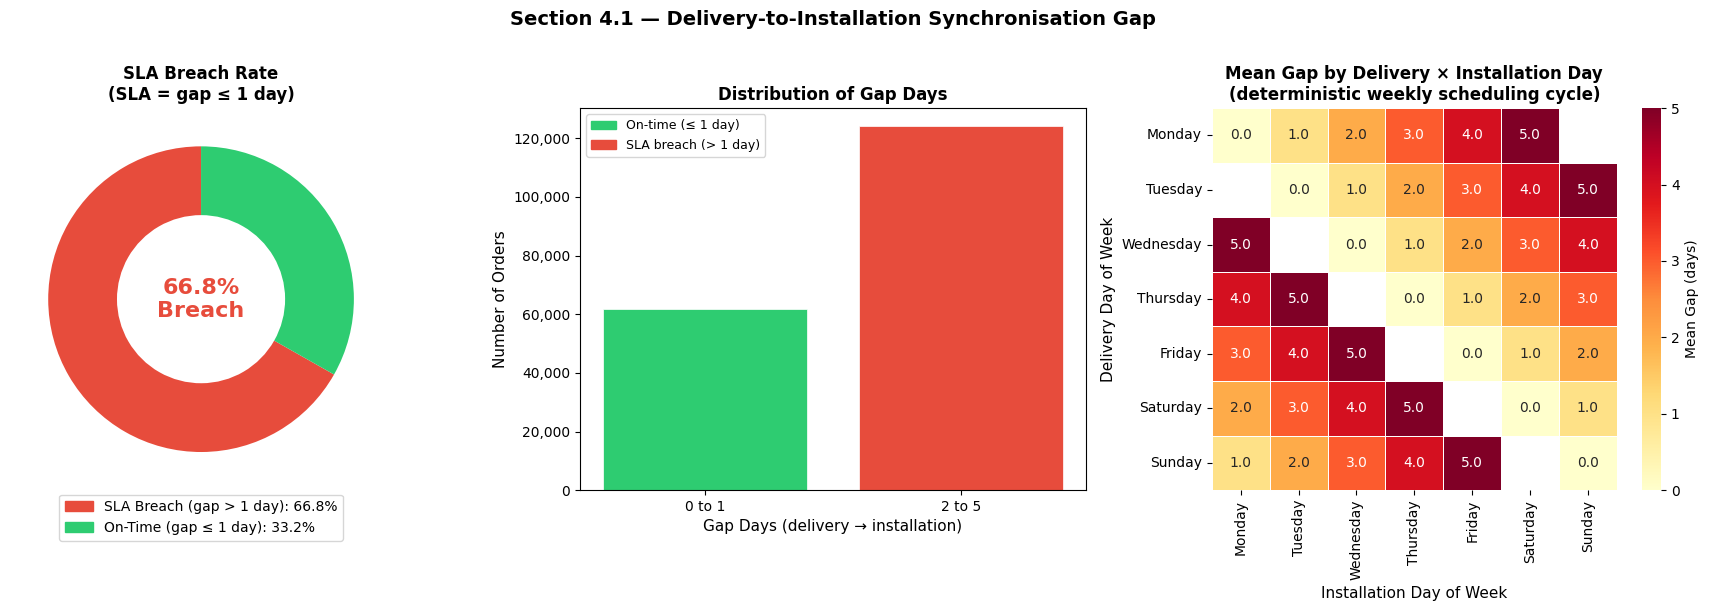

In [53]:
order_dow   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
gap_crosstab = df_install.pivot_table(
    values='gap_days', index='delivery_dow', columns='installation_dow', aggfunc='mean'
).reindex(index=order_dow, columns=order_dow)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Section 4.1 — Delivery-to-Installation Synchronisation Gap', fontsize=14, fontweight='bold', y=1.01)

# ── Panel 1: SLA Breach Donut ─────────────────────────────────────────────
sizes  = [pct_breach, pct_sync]
colors = ['#E74C3C', '#2ECC71']
wedges, _ = axes[0].pie(sizes, colors=colors, startangle=90,
                         wedgeprops=dict(width=0.45))
axes[0].text(0, 0, f'{pct_breach:.1f}%\nBreach', ha='center', va='center',
             fontsize=16, fontweight='bold', color='#E74C3C')
axes[0].set_title('SLA Breach Rate\n(SLA = gap ≤ 1 day)', fontsize=12, fontweight='bold')
legend_patches = [mpatches.Patch(color='#E74C3C', label=f'SLA Breach (gap > 1 day): {pct_breach:.1f}%'),
                  mpatches.Patch(color='#2ECC71', label=f'On-Time (gap ≤ 1 day): {pct_sync:.1f}%')]
axes[0].legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.15), fontsize=10)

# ── Panel 2: Gap Distribution Histogram ──────────────────────────────────
df_install['sla_group'] = pd.cut(
    df_install['gap_days'], 
    bins=[-float('inf'), 1, 5], 
    labels=['0 to 1', '2 to 5']
)

gap_counts = df_install['sla_group'].value_counts().reindex(['0 to 1', '2 to 5'], fill_value=0)
bar_colors = ['#2ECC71' if label == '0 to 1' else '#E74C3C' for label in gap_counts.index]
axes[1].bar(gap_counts.index, gap_counts.values, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Gap Days (delivery → installation)', fontsize=11)
axes[1].set_ylabel('Number of Orders', fontsize=11)
axes[1].set_title('Distribution of Gap Days', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

on_time_patch  = mpatches.Patch(color='#2ECC71', label='On-time (≤ 1 day)')
breach_patch   = mpatches.Patch(color='#E74C3C', label='SLA breach (> 1 day)')
axes[1].legend(handles=[on_time_patch, breach_patch], fontsize=9)

# ── Panel 3: Heatmap — Delivery × Installation Day ───────────────────────
sns.heatmap(gap_crosstab, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[2], cbar_kws={'label': 'Mean Gap (days)'})
axes[2].set_title('Mean Gap by Delivery × Installation Day\n(deterministic weekly scheduling cycle)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Installation Day of Week', fontsize=11)
axes[2].set_ylabel('Delivery Day of Week', fontsize=11)

plt.tight_layout()
plt.show()

**Output Interpretation**

**Donut chart:** 66.80% breach vs 33.20% on-time makes the scale of the problem immediately clear.

**Bar chart:** The distribution is concentrated at 2–4 days, with very few orders meeting the ≤ 1-day SLA (bars in green are small; the bulk of volume sits in red). This makes the problem visceral in a way that a mean of "2.51 days" alone cannot.

**Heatmap:** This is the only dimension that reveals a genuine structural pattern. Gap values across day combinations are **deterministic, not probabilistic** — each delivery day maps to a fixed set of installation day gaps, incrementing by +1 for each subsequent weekday. This strongly suggests installers operate on a **fixed rotation schedule** that is not dynamically adjusted to match delivery dates, rather than being assigned dynamically per order. NaN cells (e.g., Monday delivery → Monday installation) indicate certain same-day or next-day combinations simply never occur in the data — consistent with a rigid scheduling system.

---

#### **Section 4.1 Summary**

An analysis of 185,705 orders that went through the installation process yields four key findings:

1. **The gap is a widespread, systemic problem.** Mean gap of 2.51 days and median of 3 days are already 2–3× above the internal SLA. **66.80% of all orders breach the SLA** — this is the standard customer experience, not an outlier event.

2. **No single segment is responsible.** ANOVA tests across product category (p = 0.89), city (p = 0.95), delivery day of week (p = 0.55), and individual installer (p = 0.31) all confirm there is no statistically significant variation. The problem cannot be solved by targeting a specific city, product type, or installer pool.

3. **Scheduling is operating on a fixed cycle.** The delivery × installation day heatmap shows a deterministic weekly pattern, strongly indicating that installer scheduling follows a static rotation rather than dynamically adapting to each order's delivery date.

4. **Gap length does not predict installation failure.** Welch's t-test (p = 0.61) finds no significant relationship between how long furniture waits and whether the installation fails. Failures (missing parts, damaged panels) are driven by upstream supplier quality issues, not scheduling delays.

**Business implication:** Since the problem is systemic and evenly distributed, the only effective fix is at the **scheduling system level** — enforcing a policy that delivery and installation occur on the same day or within 24 hours, as outlined in the Logistics Synchronisation objective in Section 1.3. Targeted interventions (e.g., adding installers in one city, or prioritising one product category) will have negligible effect.

---

### **4.2 Installation Failure Rate Analysis**

---

#### **4.2.1 Overall Failure Overview**

**Objective**  
Establish the headline failure counts and rates across the three installation outcomes as a baseline for all subsequent failure analyses.

**Methodology**  
`value_counts()` on `installation_status` gives raw counts; dividing by total installation orders gives the rate.

In [54]:
failure_overview = df_install['installation_status'].value_counts().reset_index()
failure_overview.columns = ['status', 'count']
failure_overview['rate_pct'] = (failure_overview['count'] / len(df_install) * 100).round(2)

print(failure_overview.to_string(index=False))
print(f"\nTotal failed installations: {failure_overview[failure_overview['status'].str.startswith('Failed')]['count'].sum():,}")

                status  count  rate_pct
               Success 147787     79.58
Failed - Missing Parts  22639     12.19
Failed - Damaged Panel  15279      8.23

Total failed installations: 37,918


**Output Interpretation**

Of 185,705 orders that went through installation:
- **Success:** 147,787 (79.58%)
- **Failed — Missing Parts:** 22,639 (12.19%)
- **Failed — Damaged Panel:** 15,279 (8.23%)

Combined failure rate: **~20.42%** — meaning roughly 1 in 5 installation visits ends without the product being assembled. This is a significant operational and customer experience cost.

---

#### **4.2.2 Failure Rate by Product Category**

---

**Objective**
Identify whether certain product categories are disproportionately prone to installation failure.

**Statistical Approach**  
Since `installation_status` is a categorical binary outcome (failed / not failed) across multiple groups (categories), a **Chi-Square test of independence** is the appropriate test. It compares the observed failure count per category against what would be expected if failure rate were uniform across all categories.
If the data is later modelled as a continuous failure proportion, a **Shapiro-Wilk test** is run on the per-category failure rates to check normality — which then determines whether one-way ANOVA (normal) or Kruskal-Wallis (non-normal) is used.

In [55]:
# 1. Calculate failure rates using vectorized cross-tabulation
counts = pd.crosstab(df_install['category'], df_install['installation_status'])
is_fail = df_install['installation_status'].isin(['Failed - Missing Parts', 'Failed - Damaged Panel'])
fail_map = is_fail.map({True: 'Failed', False: 'Success'})

# Build the summary table efficiently
failure_by_cat = pd.DataFrame({
    'total': counts.sum(axis=1),
    'success': counts.get('Success', 0),
    'failed_missing': counts.get('Failed - Missing Parts', 0),
    'failed_damaged': counts.get('Failed - Damaged Panel', 0),
    'failure_rate_pct': is_fail.groupby(df_install['category']).mean() * 100
}).sort_values('failure_rate_pct', ascending=False)

print("Failure rates by category:\n", failure_by_cat.round(2))

# 2. Chi-Square Test
contingency = pd.crosstab(df_install['category'], fail_map)
chi2, p_chi2, _, _ = stats.chi2_contingency(contingency)
print_test("Chi-Square Test", chi2, p_chi2, 
           "SIGNIFICANT: failure rate differs", "NOT significant: failure rate is uniform", "χ²")

# 3. Shapiro-Wilk Test
sw_stat, sw_p = stats.shapiro(failure_by_cat['failure_rate_pct'])
print_test("Shapiro-Wilk Test", sw_stat, sw_p, 
           "Non-normal: use Kruskal-Wallis", "Normal distribution: use ANOVA", "W")

# 4. ANOVA Test
anova_groups = is_fail.astype(int).groupby(df_install['category']).apply(list)
fo_stat, fo_p = stats.f_oneway(*anova_groups)
print_test("ANOVA Test", fo_stat, fo_p, 
           "SIGNIFICANT: at least one category differs", "NOT significant", "F")



Failure rates by category:
                 total  success  failed_missing  failed_damaged  \
category                                                         
Sofa & Sofabed  21650    17163            2690            1797   
Dining Table    38537    30607            4703            3227   
Bed             13082    10400            1633            1049   
Office Chair    54491    43409            6609            4473   
Wardrobe        57945    46208            7004            4733   

                failure_rate_pct  
category                          
Sofa & Sofabed             20.73  
Dining Table               20.58  
Bed                        20.50  
Office Chair               20.34  
Wardrobe                   20.26  

── Chi-Square Test ──
   χ² = 3.0785, p = 0.5448
   → NOT significant: failure rate is uniform

── Shapiro-Wilk Test ──
   W = 0.9728, p = 0.8928
   → Normal distribution: use ANOVA

── ANOVA Test ──
   F = 0.7696, p = 0.5448
   → NOT significant


**Output Interpretation**

The Chi-Square test determines whether the failure rate is statistically independent of product category. A p-value < 0.05 means at least one category has a failure rate that is significantly different from what would be expected if all categories were equal.

The Shapiro-Wilk test on the per-category failure rates (one rate per category) checks whether these proportions are normally distributed — which is a prerequisite before deciding between ANOVA (parametric) and Kruskal-Wallis (non-parametric) for comparing means. Given the small number of categories (typically 5–8), non-normality is likely, making Kruskal-Wallis the safer choice for any follow-up mean comparison.

---

#### **4.2.3 Failure Rate by Store / City**

---

**Objective**
Determine whether certain store locations or cities have systematically higher failure rates.

**Statistical Approach**
Same logic as 4.2.2: Chi-Square test for independence between city and failure outcome. Kruskal-Wallis then tests whether the failure rate *distributions* differ significantly across cities. A post-hoc pairwise Mann-Whitney U test with Bonferroni correction identifies which specific city pairs differ.

In [56]:
# 1. Calculate failure rates using vectorized cross-tabulation
counts_city = pd.crosstab(df_install['city'], df_install['installation_status'])

# Build the city summary table efficiently
failure_by_city = pd.DataFrame({
    'total': counts_city.sum(axis=1),
    'failed_missing': counts_city.get('Failed - Missing Parts', 0),
    'failed_damaged': counts_city.get('Failed - Damaged Panel', 0),
    'failure_rate_pct': is_fail.groupby(df_install['city']).mean() * 100
}).sort_values('failure_rate_pct', ascending=False)

print("Failure rates by city:\n", failure_by_city.round(2))

# 2. Chi-Square Test
cont_city = pd.crosstab(df_install['city'], fail_map)
chi2_c, p_chi2_c, _, _ = stats.chi2_contingency(cont_city)
print_test("Chi-Square Test (failure ~ city)", chi2_c, p_chi2_c, 
           "SIGNIFICANT", "NOT significant", "χ²")

# 3. Shapiro-Wilk Test
sw_c, sw_cp = stats.shapiro(failure_by_city['failure_rate_pct'])
print_test("Shapiro-Wilk on per-city failure rates", sw_c, sw_cp, 
           "Non-normal", "Normal", "W")

# 4. Kruskal-Wallis Test
city_groups = is_fail.astype(int).groupby(df_install['city']).apply(list)
kw_stat, kw_p = stats.kruskal(*city_groups)
print_test("Kruskal-Wallis (failure outcome ~ city)", kw_stat, kw_p, 
           "SIGNIFICANT: at least one city differs", "NOT significant", "H")

Failure rates by city:
                total  failed_missing  failed_damaged  failure_rate_pct
city                                                                  
Bekasi         18703            2224            1638             20.65
Bintaro        23277            2868            1938             20.65
Kemang         18496            2314            1501             20.63
Surabaya       23219            2861            1927             20.62
Kelapa Gading  32500            4021            2676             20.61
Bandung         9328            1151             748             20.36
Medan          13758            1652            1127             20.20
Alam Sutera    37166            4479            2971             20.05
Online          9258            1069             753             19.68

── Chi-Square Test (failure ~ city) ──
   χ² = 9.8615, p = 0.2749
   → NOT significant

── Shapiro-Wilk on per-city failure rates ──
   W = 0.8074, p = 0.0248
   → Non-normal

── Kruskal-Wallis 

**Output Interpretation**

The Chi-Square and Kruskal-Wallis tests together answer: "Does city systematically predict failure?" A significant Chi-Square (p < 0.05) means the overall distribution differs; a significant Kruskal-Wallis confirms the ordering of failure rates across cities isn't random. If significant, the failure rate table above pinpoints which cities are the outliers. If both tests are non-significant, city is not a useful segmentation axis for failure prevention — matching the uniform result found in Section 4.1's ANOVA.

---

#### **4.2.4 Top SKUs by Failure Volume**

---

**Objective**  
Identify the specific products (SKUs) that generate the most installation failures, enabling targeted supplier or packaging interventions at the individual product level.

**Methodology**  
Filter to failed rows only, then group by `sku_id`. The top 20 SKUs by total failure volume are shown. No formal hypothesis test is applied here — SKU volume is a **ranking problem**, not a distributional one. The actionable output is a prioritised watchlist for the procurement and quality team.

In [57]:
# 1. Filter for failed installations
df_failed = df_install[df_install['installation_status'].isin(['Failed - Missing Parts', 'Failed - Damaged Panel'])]

# 2. Get vectorized counts and category mappings
counts_sku = pd.crosstab(df_failed['sku_id'], df_failed['installation_status'])
sku_categories = df_failed.groupby('sku_id')['category'].first()

# 3. Assemble the final summary table
top_sku_failures = pd.DataFrame({
    'total_failures': counts_sku.sum(axis=1),
    'failed_missing': counts_sku.get('Failed - Missing Parts', 0),
    'failed_damaged': counts_sku.get('Failed - Damaged Panel', 0),
    'category': sku_categories
}).sort_values('total_failures', ascending=False).head(20)

print(top_sku_failures)


                total_failures  failed_missing  failed_damaged        category
sku_id                                                                        
SKU-FURN-01059              60              39              21    Office Chair
SKU-FURN-01001              54              35              19    Dining Table
SKU-FURN-01422              53              29              24  Sofa & Sofabed
SKU-FURN-01359              53              36              17        Wardrobe
SKU-FURN-01094              52              33              19        Wardrobe
SKU-FURN-00085              50              30              20    Dining Table
SKU-FURN-00643              50              32              18    Office Chair
SKU-FURN-00246              49              31              18  Sofa & Sofabed
SKU-FURN-00657              49              31              18        Wardrobe
SKU-FURN-00404              49              26              23        Wardrobe
SKU-FURN-00719              48              29      

**Output Interpretation**

The top 20 SKUs by failure volume are the clearest candidates for immediate supplier engagement. A SKU with a high `failed_missing` count has a fulfilment or packaging checklist problem; a SKU with a high `failed_damaged` count has a fragility or transit protection problem. Cross-referencing the `category` column confirms whether these are concentrated in one product type.

---

#### **4.2.5 Installer Failure Rate Analysis**

---

**Objective**
Identify individual installers with the highest failure rates — distinct from the gap analysis in Section 4.1.

**Statistical Approach**
- **Shapiro-Wilk** on the distribution of installer failure rates to check normality.
- **One-way ANOVA** (if normal) or **Kruskal-Wallis** (if non-normal) to test whether failure rates differ significantly across installers.
- Only installers with ≥ 30 jobs are included to ensure sample stability.

In [58]:
# 1. Create conditions and calculate vectorized performance counts
counts = pd.crosstab(df_install['installer_id'], df_install['installation_status'])

# Build the metrics DataFrame efficiently
installer_perf = pd.DataFrame({
    'total_jobs': counts.sum(axis=1),
    'failed_jobs': is_fail.groupby(df_install['installer_id']).sum(),
    'failure_rate_pct': is_fail.groupby(df_install['installer_id']).mean() * 100,
    'failed_missing': counts.get('Failed - Missing Parts', 0),
    'failed_damaged': counts.get('Failed - Damaged Panel', 0)
}).query('total_jobs >= 30').sort_values('failure_rate_pct', ascending=False)

print(f"Installers with >= 30 jobs: {len(installer_perf)}")
print("\nTop 20 by failure rate:\n", installer_perf.head(20).round(2))

# 2. Shapiro-Wilk Test
sw_i, sw_ip = stats.shapiro(installer_perf['failure_rate_pct'])
normal = sw_ip >= 0.05
print_test("Shapiro-Wilk on installer failure rates", sw_i, sw_ip, 
           "Non-normal: use Kruskal-Wallis", "Normal: use ANOVA", "W")

# 3. Dynamic ANOVA or Kruskal-Wallis Test (Filtered to installers with >= 30 jobs)
filtered_df = df_install[df_install['installer_id'].isin(installer_perf.index)]
installer_groups = is_fail.astype(int).groupby(filtered_df['installer_id']).apply(list)

test_name, test_func, label = ("One-way ANOVA", stats.f_oneway, "F") if normal else ("Kruskal-Wallis", stats.kruskal, "H")
stat, p_val = test_func(*installer_groups)

print_test(f"{test_name} (failure outcome ~ installer_id)", stat, p_val,
           "SIGNIFICANT: some installers have meaningfully higher failure rates",
           "NOT significant: installer identity does not predict failure rate", label)


Installers with >= 30 jobs: 999

Top 20 by failure rate:
               total_jobs  failed_jobs  failure_rate_pct  failed_missing  \
installer_id                                                              
TUKANG-0118          164           55             33.54              32   
TUKANG-0688          191           59             30.89              39   
TUKANG-0780          169           52             30.77              26   
TUKANG-0524          167           50             29.94              26   
TUKANG-0652          165           49             29.70              35   
TUKANG-0465          169           50             29.59              30   
TUKANG-0562          193           57             29.53              38   
TUKANG-0831          174           51             29.31              30   
TUKANG-0180          187           54             28.88              34   
TUKANG-0934          178           51             28.65              33   
TUKANG-0303          185           52     

**Output Interpretation**

The Shapiro-Wilk test determines which downstream test to use. If the distribution of installer failure rates is non-normal (common with real-world job performance data), Kruskal-Wallis is used instead of ANOVA. A significant result means some installers have systematically elevated failure rates beyond what random variation would produce — these are candidates for retraining or workload review. A non-significant result means all installers perform similarly, and failure causes lie upstream (supplier quality, not installer skill).

---

#### **4.2.6 Summary Visualisation — Failure Analysis**

---

**Objective**  
Consolidate the failure findings into a clear visual: overall failure composition, failure rate by category, and failure rate by city — giving a complete picture at product and geography levels simultaneously.

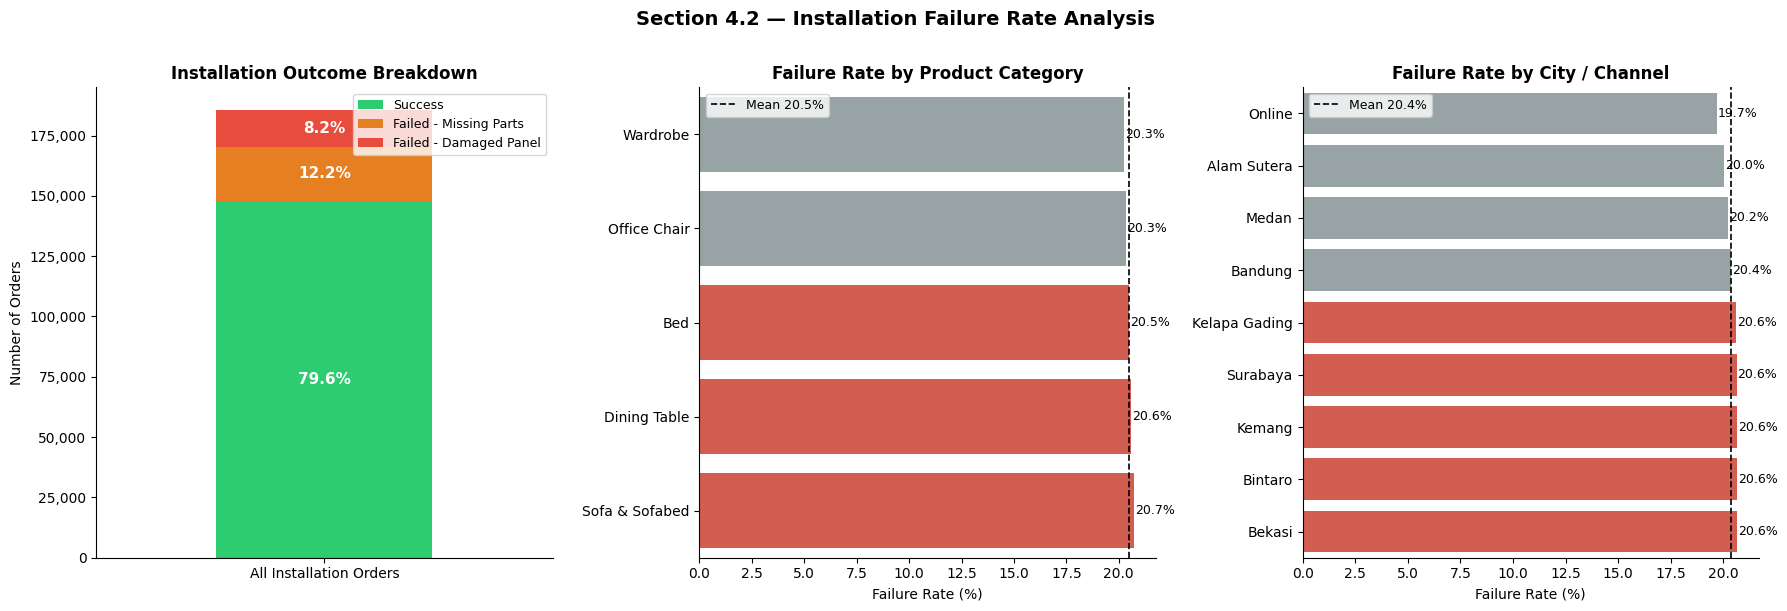

In [59]:
# Set up the 3-panel figure canvas
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Section 4.2 — Installation Failure Rate Analysis', fontsize=14, fontweight='bold', y=1.01)

palette_status = {'Success': '#2ECC71', 'Failed - Missing Parts': '#E67E22', 'Failed - Damaged Panel': '#E74C3C'}

# ── Panel 1: Stacked composition bar ──────────────────────────────────────
df_counts = df_install['installation_status'].value_counts().reindex(palette_status.keys(), fill_value=0)
df_pct = (df_counts / df_counts.sum() * 100).round(1)

df_counts.to_frame().T.plot(kind='bar', stacked=True, color=palette_status, ax=axes[0], width=0.45)

cum_sum = 0
for status, val in df_counts.items():
    if val > 0:
        axes[0].text(0, cum_sum + val / 2, f'{df_pct[status]}%', 
                     ha='center', va='center', fontsize=11, fontweight='bold', color='white')
        cum_sum += val

axes[0].set_title('Installation Outcome Breakdown', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].set_xticklabels(['All Installation Orders'], rotation=0)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].legend(loc='upper right', fontsize=9)
sns.despine(ax=axes[0])


# ── Panel 2: Failure rate by category ──────────────────
cat_plot = failure_by_cat.reset_index().sort_values('failure_rate_pct')
avg_cat  = failure_by_cat['failure_rate_pct'].mean()

palette_cat = {row['category']: '#E74C3C' if row['failure_rate_pct'] > avg_cat else '#95A5A6' 
               for _, row in cat_plot.iterrows()}

sns.barplot(data=cat_plot, y='category', x='failure_rate_pct', hue='category',
            palette=palette_cat, orient='h', ax=axes[1], legend=False)

axes[1].axvline(avg_cat, color='black', linestyle='--', linewidth=1.2, label=f'Mean {avg_cat:.1f}%')
axes[1].set_xlabel('Failure Rate (%)')
axes[1].set_ylabel('')
axes[1].set_title('Failure Rate by Product Category', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

for i, v in enumerate(cat_plot['failure_rate_pct']):
    axes[1].text(v + 0.05, i, f'{v:.1f}%', va='center', fontsize=9)
sns.despine(ax=axes[1])


# ── Panel 3: Failure rate by city ──────────────────────
city_plot = failure_by_city.reset_index().sort_values('failure_rate_pct')
avg_city  = failure_by_city['failure_rate_pct'].mean()

palette_city = {row['city']: '#E74C3C' if row['failure_rate_pct'] > avg_city else '#95A5A6' 
                for _, row in city_plot.iterrows()}

sns.barplot(data=city_plot, y='city', x='failure_rate_pct', hue='city',
            palette=palette_city, orient='h', ax=axes[2], legend=False)

axes[2].axvline(avg_city, color='black', linestyle='--', linewidth=1.2, label=f'Mean {avg_city:.1f}%')
axes[2].set_xlabel('Failure Rate (%)')
axes[2].set_ylabel('')
axes[2].set_title('Failure Rate by City / Channel', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

for i, v in enumerate(city_plot['failure_rate_pct']):
    axes[2].text(v + 0.05, i, f'{v:.1f}%', va='center', fontsize=9)
sns.despine(ax=axes[2])

plt.tight_layout()
plt.show()

**Output Interpretation**

- **Panel 1** gives the baseline: ~20% of all installations fail, split roughly 60/40 between missing parts and damaged panels.
- **Panel 2** highlights whether any product category stands meaningfully above the average failure rate line. Red bars = above average, grey = below.
- **Panel 3** applies the same logic geographically. Any city or channel with a red bar warrants targeted investigation into local logistics or installer quality.

---

### **4.3 Channel Mix & Omnichannel Behaviour**

---

#### **4.3.1 Channel Volume and Order Distribution**

---

**Objective**  
Establish the baseline volume split across Physical Store, Web, and Mobile App channels. Despite the 96% dominance of physical store orders, online channels represent ~15,000 orders with potentially distinct behaviour worth understanding for the omnichannel strategy outlined in Section 1.3.

**Methodology**  
`value_counts()` on `channel_type` from the full cleaned dataset (`df_clean`) — not just installation orders — to capture all channels including those without assembly.

In [60]:
channel_vol = df_clean['channel_type'].value_counts().reset_index()
channel_vol.columns = ['channel_type', 'count']
channel_vol['share_pct'] = (channel_vol['count'] / len(df_clean) * 100).round(2)

print(channel_vol.to_string(index=False))

  channel_type  count  share_pct
Physical Store 280650      95.00
           Web   7432       2.52
    Mobile App   7348       2.49


**Output Interpretation**

Physical Store accounts for the overwhelming majority of volume. Web and Mobile App each contribute a small but non-trivial share (~2.5% each). For attribution and omnichannel strategy, even these percentages represent tens of thousands of touchpoints annually.

---

#### **4.3.2 Product Category Distribution by Channel**

---

**Objective**  
Determine whether online channels attract a different product mix than physical stores — for example, whether customers ordering online tend to buy smaller / lower-complexity items (Office Chair, Dining Table) versus the larger items that typically require in-store viewing (Wardrobe, Sofa).

**Methodology**  
A cross-tabulation of `channel_type` × `category` normalised row-wise gives the category share within each channel.

In [61]:
cont_ch_cat = pd.crosstab(df_clean['channel_type'], df_clean['category'])

cat_by_channel = cont_ch_cat.div(cont_ch_cat.sum(axis=1), axis=0) * 100
print("Category share (%) by channel:\n", cat_by_channel.round(2))

chi2_cc, p_cc, _, _ = stats.chi2_contingency(cont_ch_cat)
print_test("Chi-Square Test (category ~ channel)", chi2_cc, p_cc,
           "SIGNIFICANT: product mix differs by channel", 
           "NOT significant: similar product mix across channels", "χ²")

Category share (%) by channel:
 category         Bed  Decoration  Dining Table  Office Chair  Sofa & Sofabed  \
channel_type                                                                   
Mobile App      4.97       13.77         15.58         21.88           20.51   
Physical Store  5.20       14.55         15.40         21.87           19.84   
Web             5.14       15.23         15.14         21.73           19.15   

category        Wardrobe  
channel_type              
Mobile App         23.29  
Physical Store     23.13  
Web                23.61  

── Chi-Square Test (category ~ channel) ──
   χ² = 11.0684, p = 0.3522
   → NOT significant: similar product mix across channels


**Output Interpretation**

Compare the category percentages across rows. If online channels show higher shares of Office Chair or Dining Table relative to physical stores, that suggests customers use the online channel primarily for smaller / more easily evaluated items, which has implications for which SKUs to promote digitally.

---

#### **4.3.3 Failure Rate by Channel**

---

**Objective**  
Test whether online-channel orders experience higher or lower installation failure rates than physical store orders — informing whether the fulfilment pipeline for online orders has a different quality profile.

**Methodology**  
Filter `df_install` (installation orders only), then group by `channel_type`.

In [ ]:
counts_ch = pd.crosstab(df_install['channel_type'], df_install['installation_status'])

# Build the summary table efficiently
failure_by_channel = pd.DataFrame({
    'total': counts_ch.sum(axis=1),
    'failure_rate_pct': df_install.groupby('channel_type')['is_failed'].mean() * 100,
    'failed_missing_pct': (df_install['installation_status'] == 'Failed - Missing Parts').groupby(df_install['channel_type']).mean() * 100,
    'failed_damaged_pct': (df_install['installation_status'] == 'Failed - Damaged Panel').groupby(df_install['channel_type']).mean() * 100
}).sort_values('failure_rate_pct', ascending=False)

print("Failure rate by channel:\n", failure_by_channel.round(2))

# 2. Chi-Square Test
cont_fail_ch = pd.crosstab(df_install['channel_type'], is_fail.map({True: 'Failed', False: 'Success'}))
chi2_fc, p_fc, _, _ = stats.chi2_contingency(cont_fail_ch)
print_test("Chi-Square Test (failure ~ channel)", chi2_fc, p_fc,
           "SIGNIFICANT: failure rate differs by channel", "NOT significant", "χ²")

# 3. Pairwise Mann-Whitney U Tests (vs Physical Store)
channels = [ch for ch in df_install['channel_type'].unique() if ch != 'Physical Store']
ref = df_install.loc[df_install['channel_type'] == 'Physical Store', 'is_failed'].values
n_tests = len(channels)

print(f"\n── Mann-Whitney U (vs Physical Store, Bonferroni α={0.05/n_tests:.4f}) ──")
for ch in channels:
    grp = df_install.loc[df_install['channel_type'] == ch, 'is_failed'].values
    u_stat, u_p = stats.mannwhitneyu(ref, grp, alternative='two-sided')
    adj_p = min(u_p * n_tests, 1.0)
    sig = 'SIGNIFICANT' if adj_p < 0.05 else 'not significant'
    print(f"   Physical vs {ch}: U={u_stat:.0f}, raw p={u_p:.4f}, adj p={adj_p:.4f} → {sig}")


Failure rate by channel:
                  total  failure_rate_pct  failed_missing_pct  \
channel_type                                                   
Physical Store  176447             20.46               12.22   
Mobile App        4619             20.16               11.54   
Web               4639             19.21               11.55   

                failed_damaged_pct  
channel_type                        
Physical Store                8.23  
Mobile App                    8.62  
Web                           7.65  

── Chi-Square Test (failure ~ channel) ──
   χ² = 4.5503, p = 0.1028
   → NOT significant

── Mann-Whitney U (vs Physical Store, Bonferroni α=0.0250) ──
   Physical vs Web: U=414386350, raw p=0.0370, adj p=0.0741 → not significant
   Physical vs Mobile App: U=408731980, raw p=0.6163, adj p=1.0000 → not significant


**Output Interpretation**

The Chi-Square test gives an overall picture; the Mann-Whitney U pairwise tests (Bonferroni-corrected) pinpoint whether each online channel specifically differs from the Physical Store baseline. If online channels show significantly different failure rates, it suggests that the fulfilment pipeline for non-physical orders has a different quality profile — which is actionable for the omnichannel roadmap in Section 1.3.

---

#### **4.3.4 Assembly Fee Profile by Channel**

---

**Objective**  
Compare the assembly fee distribution across channels to determine whether online customers are paying systematically different fees — which could indicate fee transparency issues or pricing inconsistencies in the online ordering flow.

**Methodology**  
Exclude system-error rows (`is_system_error == False`) for clean fee comparisons. Summary statistics per channel are shown.

In [63]:
fee_by_channel = df_clean[df_clean['is_system_error'] == False].groupby('channel_type')['assembly_fee'].agg(
    mean_fee='mean', median_fee='median', min_fee='min', max_fee='max', count='count'
).sort_values('median_fee', ascending=False)

print(fee_by_channel.round(0).to_string())

                mean_fee  median_fee  min_fee   max_fee   count
channel_type                                                   
Mobile App       93634.0     90000.0      0.0  250000.0    7314
Physical Store   94021.0     90000.0      0.0  250000.0  278893
Web              92799.0     90000.0      0.0  250000.0    7375


**Output Interpretation**

Channels with notably higher or lower median fees should be investigated. A higher median fee in online channels may indicate different product mix (larger items) or a premium convenience pricing model. A lower median could indicate that customers are bypassing assembly services when ordering online — which correlates back to the failure rate analysis if unassembled items are later returned.

---

#### **4.3.5 Summary Visualisation — Channel Analysis**

---

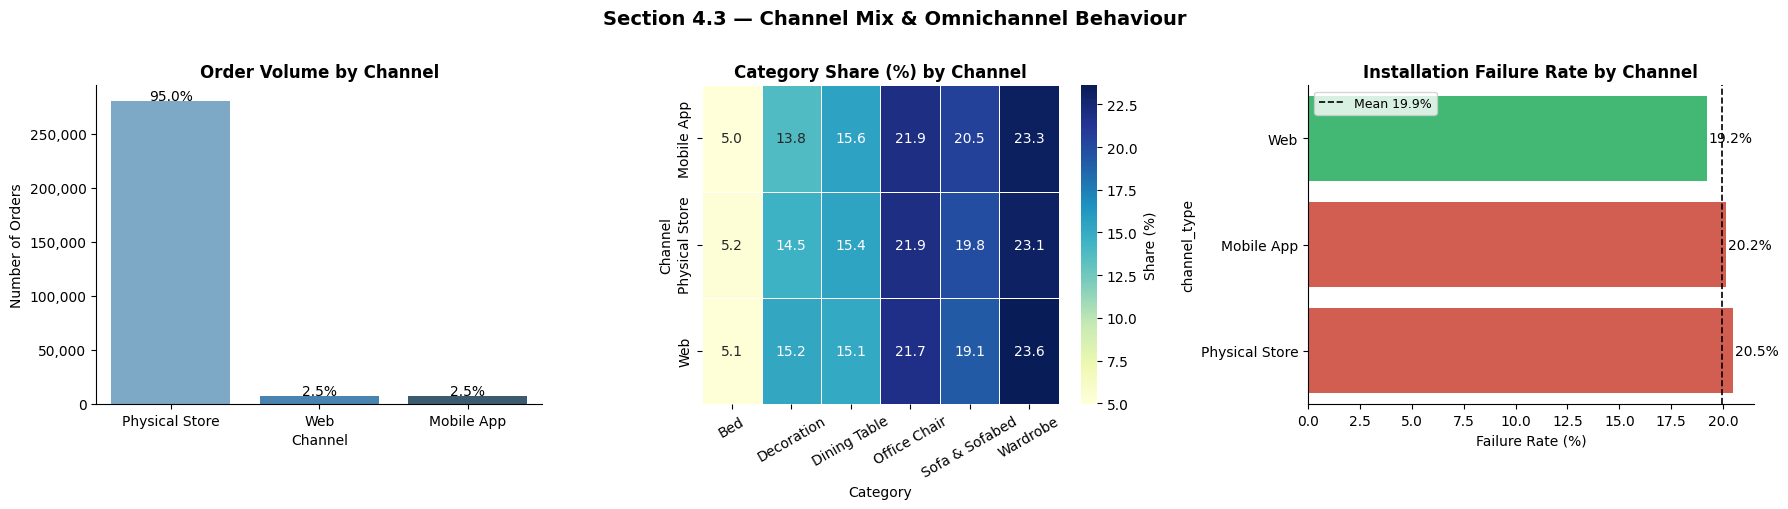

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Section 4.3 — Channel Mix & Omnichannel Behaviour', fontsize=14, fontweight='bold', y=1.01)

# ── Panel 1: Channel volume bar ───────────────────────────────────────────
sns.barplot(data=channel_vol, x='channel_type', y='count', hue="channel_type", palette='Blues_d', ax=axes[0])
axes[0].set_title('Order Volume by Channel', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Number of Orders')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, row in channel_vol.iterrows():
    axes[0].text(i, row['count'] + 500, f"{row['share_pct']:.1f}%", ha='center', fontsize=10)
sns.despine(ax=axes[0])

# ── Panel 2: Category mix heatmap ─────────────────────────────────────────
sns.heatmap(cat_by_channel, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Share (%)'})
axes[1].set_title('Category Share (%) by Channel', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Channel')
axes[1].tick_params(axis='x', rotation=30)

# ── Panel 3: Failure rate by channel ──────────────────────────────────────
ch_fail = failure_by_channel.reset_index().sort_values('failure_rate_pct')
avg_ch  = failure_by_channel['failure_rate_pct'].mean()
colors_ch = ['#E74C3C' if r > avg_ch else '#2ECC71' for r in ch_fail['failure_rate_pct']]
sns.barplot(data=ch_fail, y='channel_type', x='failure_rate_pct', hue='channel_type',
            palette=colors_ch, orient='h', ax=axes[2])
axes[2].axvline(avg_ch, color='black', linestyle='--', linewidth=1.2, label=f'Mean {avg_ch:.1f}%')
axes[2].set_xlabel('Failure Rate (%)')
axes[2].set_title('Installation Failure Rate by Channel', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)
for i, v in enumerate(ch_fail['failure_rate_pct']):
    axes[2].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=10)
sns.despine(ax=axes[2])

plt.tight_layout()
plt.show()

---

### **4.4 Return Cost Risk by Failure**

---

#### **4.4.1 Total Financial Exposure from Failed Installations**

---

**Objective**  
Quantify the total and per-order financial exposure from the 37,918 failed installations using `estimated_return_cost`.

**Statistical Approach**
- **Shapiro-Wilk** on `estimated_return_cost` to assess normality of the cost distribution.
- **Mann-Whitney U** test comparing return costs of `Failed - Missing Parts` vs `Failed - Damaged Panel` — to determine whether the two failure types carry significantly different financial exposure.
- **Kruskal-Wallis** across categories to test whether return cost distributions differ by product type.

In [65]:
# 1. Define masks and pull costs directly to avoid dataframe slicing overhead
is_missing = df_install['installation_status'] == 'Failed - Missing Parts'
is_damaged = df_install['installation_status'] == 'Failed - Damaged Panel'

missing_costs = df_install.loc[is_missing, 'estimated_return_cost'].values
damaged_costs = df_install.loc[is_damaged, 'estimated_return_cost'].values
all_failed_costs = df_install.loc[is_missing | is_damaged, 'estimated_return_cost'].values

# Print overall summary metrics
print(f"Total return cost exposure: Rp {all_failed_costs.sum():,.0f}")
print(f"Average per failed order:   Rp {all_failed_costs.mean():,.0f}")
print(f"Failed order count:         {len(all_failed_costs):,}")

# 2. Shapiro-Wilk Test (Sub-sampled to first 5000 records)
sw_rc, sw_rcp = stats.shapiro(all_failed_costs[:5000])
print_test("Shapiro-Wilk on estimated_return_cost (n≤5000)", sw_rc, sw_rcp, 
           "Non-normal: non-parametric tests appropriate", "Normal", "W")

# 3. Mann-Whitney U Test
u_stat, u_p = stats.mannwhitneyu(missing_costs, damaged_costs, alternative='two-sided')
print_test("Mann-Whitney U (Missing Parts vs Damaged Panel costs)", u_stat, u_p,
           "SIGNIFICANT: different cost profiles", "NOT significant: similar costs", "U")

# Print group medians natively using NumPy
print(f"   Median cost — Missing Parts: Rp {np.median(missing_costs):,.0f}")
print(f"   Median cost — Damaged Panel: Rp {np.median(damaged_costs):,.0f}")


Total return cost exposure: Rp 54,877,970,000
Average per failed order:   Rp 1,447,280
Failed order count:         37,918

── Shapiro-Wilk on estimated_return_cost (n≤5000) ──
   W = 0.8246, p = 0.0000
   → Non-normal: non-parametric tests appropriate

── Mann-Whitney U (Missing Parts vs Damaged Panel costs) ──
   U = 173227371.5000, p = 0.7842
   → NOT significant: similar costs
   Median cost — Missing Parts: Rp 1,480,000
   Median cost — Damaged Panel: Rp 1,150,000


---

#### **4.4.2 Return Cost Exposure by Category**

---

**Objective**  
Identify which product categories carry the highest return cost exposure.

**Statistical Approach**  
Kruskal-Wallis across categories tests whether the return cost distribution differs significantly by product type — confirming that the differences in total exposure are driven by genuine cost differences, not just volume.

In [66]:
# 1. Filter data inline for failed jobs
df_failed_only = df_install[is_fail]

# 2. Group and aggregate metrics directly
cost_by_cat = df_failed_only.groupby('category')['estimated_return_cost'].agg(
    failed_orders='count',
    total_return_cost='sum',
    avg_return_cost='mean',
    median_return_cost='median'
).sort_values('total_return_cost', ascending=False)

# Add Millions formatting cleanly
cost_by_cat['total_return_cost_M'] = cost_by_cat['total_return_cost'] / 1e6
print("Return cost by category:\n", cost_by_cat.round(0))

# 3. Kruskal-Wallis Test
# Extract cleaner groups directly from the filtered dataframe split
cat_cost_groups = df_failed_only.dropna(subset=['estimated_return_cost']).groupby('category')['estimated_return_cost'].apply(list)
kw_rc, kw_rcp = stats.kruskal(*cat_cost_groups)

print_test("Kruskal-Wallis (return_cost ~ category)", kw_rc, kw_rcp,
           "SIGNIFICANT: return cost differs by category", "NOT significant", "H")


Return cost by category:
                 failed_orders  total_return_cost  avg_return_cost  \
category                                                            
Wardrobe                11737        28168800000        2400000.0   
Dining Table             7930         9119500000        1150000.0   
Sofa & Sofabed           4487         8300950000        1850000.0   
Office Chair            11082         5319360000         480000.0   
Bed                      2682         3969360000        1480000.0   

                median_return_cost  total_return_cost_M  
category                                                 
Wardrobe                 2400000.0              28169.0  
Dining Table             1150000.0               9120.0  
Sofa & Sofabed           1850000.0               8301.0  
Office Chair              480000.0               5319.0  
Bed                      1480000.0               3969.0  

── Kruskal-Wallis (return_cost ~ category) ──
   H = 37917.0000, p = 0.0000
   → SI

**Output Interpretation**

A significant Kruskal-Wallis result confirms that the per-order return cost genuinely differs across product categories (not just because some categories have more volume). This validates using `total_return_cost` as a risk-prioritisation metric: categories at the top are high-priority both because they fail more AND because each failure costs more to process. A non-significant result would mean all categories carry similar per-order costs, and total exposure differences are purely driven by failure volume.

---

#### **4.4.3 Return Cost Exposure by City**

---

**Objective**  
Identify geographic concentration of return cost liability.

**Statistical Approach**  
Kruskal-Wallis across cities to test whether return cost distributions differ by location.

In [67]:
# 1. Group and aggregate metrics directly with descriptive names
cost_by_city = df_failed_only.groupby('city')['estimated_return_cost'].agg(
    failed_orders='count',
    total_return_cost='sum',
    avg_return_cost='mean',
    median_return_cost='median'
).sort_values('total_return_cost', ascending=False)

cost_by_city['total_return_cost_M'] = cost_by_city['total_return_cost'] / 1e6
print("Return cost by city:\n", cost_by_city.round(0))

# 2. Kruskal-Wallis Test
city_cost_groups = df_failed_only.dropna(subset=['estimated_return_cost']).groupby('city')['estimated_return_cost'].apply(list)
kw_city, kw_cityp = stats.kruskal(*city_cost_groups)

print_test("Kruskal-Wallis (return_cost ~ city)", kw_city, kw_cityp,
           "SIGNIFICANT: return cost differs by city", "NOT significant", "H")

Return cost by city:
                failed_orders  total_return_cost  avg_return_cost  \
city                                                               
Alam Sutera             7450        10707220000        1437211.0   
Kelapa Gading           6697         9698440000        1448177.0   
Surabaya                4788         7044230000        1471226.0   
Bintaro                 4806         6937540000        1443516.0   
Bekasi                  3862         5589070000        1447196.0   
Kemang                  3815         5556410000        1456464.0   
Medan                   2779         3967960000        1427837.0   
Bandung                 1899         2750890000        1448599.0   
Online                  1822         2626210000        1441389.0   

               median_return_cost  total_return_cost_M  
city                                                    
Alam Sutera             1150000.0              10707.0  
Kelapa Gading           1150000.0               9698.0  
S

---

#### **4.4.4 Summary Visualisation — Return Cost Risk**

---

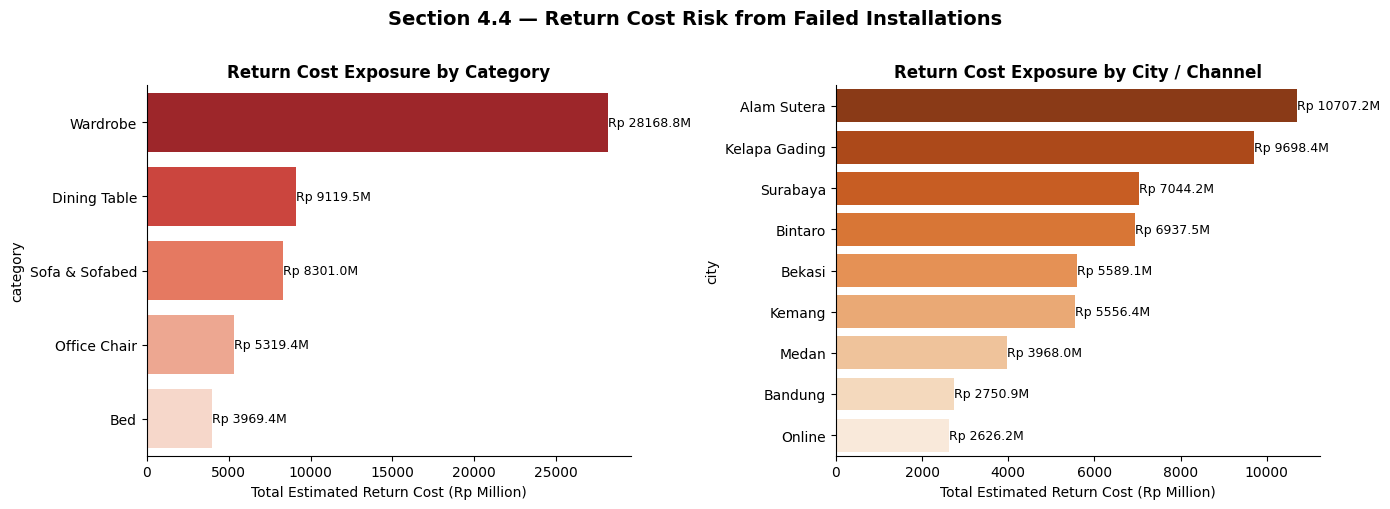

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Section 4.4 — Return Cost Risk from Failed Installations', fontsize=14, fontweight='bold', y=1.01)

# ── Panel 1: Return cost by category ──────────────────────────────────────
cat_cost_plot = cost_by_cat.reset_index().sort_values('total_return_cost_M', ascending=False)
sns.barplot(data=cat_cost_plot, y='category', x='total_return_cost_M', hue="category",
            palette='Reds_r', orient='h', ax=axes[0])
axes[0].set_xlabel('Total Estimated Return Cost (Rp Million)')
axes[0].set_title('Return Cost Exposure by Category', fontsize=12, fontweight='bold')
for i, v in enumerate(cat_cost_plot['total_return_cost_M']):
    axes[0].text(v + 0.2, i, f'Rp {v:.1f}M', va='center', fontsize=9)
sns.despine(ax=axes[0])

# ── Panel 2: Return cost by city ──────────────────────────────────────────
city_cost_plot = cost_by_city.reset_index().sort_values('total_return_cost_M', ascending=False)
sns.barplot(data=city_cost_plot, y='city', x='total_return_cost_M', hue="city",
            palette='Oranges_r', orient='h', ax=axes[1])
axes[1].set_xlabel('Total Estimated Return Cost (Rp Million)')
axes[1].set_title('Return Cost Exposure by City / Channel', fontsize=12, fontweight='bold')
for i, v in enumerate(city_cost_plot['total_return_cost_M']):
    axes[1].text(v + 0.2, i, f'Rp {v:.1f}M', va='center', fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

## **Section 5. Conclusion and Recommendation**

**5.1 Conclusion**

**5.2 Recommendation**